In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

import ast

# Preparación del dataset `listings.csv`

En este notebook, se ve detalladamente los datos de la tabla `listings.csv` para poder preparar el DAG de dicho dataset. Para ello, primero se entiende todas las variables que tiene y después se va más específicamente a cada una, viendo su distribución, outliers, valores faltantes...

## Explicación del dataset

### Información del Alojamiento

| Variable       | Tipo     | Descripción                                                                       |
| :------------- | :------- | :-------------------------------------------------------------------------------- |
| id             | Integer  | Identificador único de Airbnb para el anuncio.                                    |
| name           | Text     | Nombre del alojamiento.                                                           |
| description    | Text     | Descripción detallada del anuncio.                                                |
| room_type      | Text     | Tipo de habitación: Entire home/apt, Private room, Shared room o Hotel.           |
| accommodates   | Integer  | Capacidad máxima de personas.                                                     |
| bathrooms      | Integer  | Cantidad de baños.                                                                |
| bedrooms       | Integer  | Número de habitaciones.                                                           |
| beds           | Integer  | Número de camas.                                                                  |
| amenities      | JSON     | Lista de servicios incluidos (Wifi, Cocina, Calefacción, etc.).                   |
| price          | Currency | Precio diario del alojamiento.                                                    |

---

### Información del Anfitrión (Host)

| Variable                                    | Tipo           | Descripción                                                                |
| :------------------------------------------ | :------------- | :------------------------------------------------------------------------- |
| host_id                                     | Integer        | Identificador único del anfitrión.                                         |
| host_name                                   | Text           | Nombre del anfitrión.                                                      |
| host_since                                  | Date           | Fecha en la que el anfitrión se registró en Airbnb.                        |
| host_is_superhost                           | Boolean        | Indica si el anfitrión tiene estatus de Superhost.                         |
| host_has_profile_pic | Boolean | Flag derivado de `host_picture_url`. |
host_location|Text|Ubicación declarada por el anfitrión (útil para identificar si es un host local o a distancia).
| host_identity_verified                      | Boolean        | Indica si la identidad del anfitrión ha sido verificada.                   |
| host_response_time                          | Text           | Tiempo promedio de respuesta del anfitrión.                                |
| host_acceptance_rate                        | Text           | Tasa de aceptación de solicitudes de reserva.                              |
| host_response_rate                          | Text / Numeric | Porcentaje de mensajes a los que responde el anfitrión.                    |
| host_listings_count                         | Integer        | Número de alojamientos del anfitrión dentro del dataset.                   |
| host_total_listings_count                   | Integer        | Número total de alojamientos del anfitrión (incluyendo fuera del dataset). |
| host_verifications                          | JSON / Text    | Métodos usados para verificar la identidad (email, teléfono, etc.).        |
| calculated_host_listing_count               | Integer        | Número total de alojamientos calculado por Airbnb para ese host.           |
| calculated_host_listing_count_entire_homes  | Integer        | Número de alojamientos completos del host.                                 |
| calculated_host_listing_count_private_rooms | Integer        | Número de habitaciones privadas del host.                                  |
| calculated_host_listing_count_shared_rooms  | Integer        | Número de habitaciones compartidas del host.                               |

---

### Ubicación y Disponibilidad

| Variable                     | Tipo    | Descripción                                       |
| :--------------------------- | :------ | :------------------------------------------------ |
| neighbourhood_cleansed       | Text    | Barrio geocodificado mediante latitud y longitud. |
| neighbourhood_group_cleansed | Text    | Distrito o grupo de barrios (si aplica).          |
| neighborhood_overview        | Text    | Resumen del barrio.                               |
| latitude                     | Numeric | Latitud geográfica.                               |
| longitude                    | Numeric | Longitud geográfica.                              |
| has_availability             | Boolean | Si el anuncio está disponible actualmente.        |
| availability_30              | Integer | Días disponibles en los próximos 30 días.         |
| availability_60              | Integer | Días disponibles en los próximos 60 días.         |
| availability_90              | Integer | Días disponibles en los próximos 90 días.         |
| availability_365             | Integer | Días disponibles en los próximos 365 días.        |
| availability_eoy             | Integer | Número de días disponibles hasta final de año.    |
| estimated_occupancy_l365d    | Numeric | Ocupación estimada en los últimos 365 días.       |

---

### Reseñas y Calificaciones

| Variable                    | Tipo    | Descripción                                                     |
| :-------------------------- | :------ | :-------------------------------------------------------------- |
| number_of_reviews           | Integer | Cantidad total de reseñas recibidas.                            |
| first_review                | Date    | Fecha de la primera reseña.                                     |
| last_review                 | Date    | Fecha de la reseña más reciente.                                |
| number_of_reviews_ltm       | Integer | Número de reseñas en los últimos 12 meses.                      |
| number_of_reviews_l30d      | Integer | Número de reseñas en los últimos 30 días.                       |
| number_of_reviews_ly        | Integer | Número de reseñas durante el año pasado.                        |
| review_scores_rating        | Numeric | Puntuación general de la experiencia.                           |
| review_scores_location      | Numeric | Puntuación de la ubicación.                                     |
| review_scores_value         | Numeric | Puntuación de la relación calidad-precio.                       |
| reviews_per_month           | Numeric | Promedio mensual de reseñas.                                    |
| review_scores_accuracy      | Numeric | Puntuación sobre si el alojamiento coincide con la descripción. |
| review_scores_cleanliness   | Numeric | Puntuación sobre limpieza.                                      |
| review_scores_checkin       | Numeric | Puntuación sobre la experiencia de check-in.                    |
| review_scores_communication | Numeric | Puntuación sobre la comunicación con el anfitrión.              |

---

### Reglas de Reserva

| Variable               | Tipo    | Descripción                                                        |
| :--------------------- | :------ | :----------------------------------------------------------------- |
| minimum_nights         | Integer | Mínimo de noches requeridas para reservar.                         |
| maximum_nights         | Integer | Máximo de noches permitidas.                                       |
| instant_bookable       | Boolean | Indica si se puede reservar al instante sin confirmación manual.   |
| minimum_minimum_nights | Integer | Valor mínimo histórico del mínimo de noches requerido.             |
| maximum_minimum_nights | Integer | Valor máximo histórico del mínimo de noches requerido.             |
| minimum_maximum_nights | Integer | Valor mínimo histórico del máximo de noches permitido.             |
| maximum_maximum_nights | Integer | Valor máximo histórico del máximo de noches permitido.             |
| minimum_nights_avg_ntm | Numeric | Promedio del mínimo de noches requeridas en los próximos 12 meses. |
| maximum_nights_avg_ntm | Numeric | Promedio del máximo de noches permitidas en los próximos 12 meses. |

### Variables innecesarias

| Variable | Tipo | Razón para no considerar |
| :--- | :--- | :--- |
| property_type  | Text     | Tipo de propiedad seleccionado por el anfitrión (Casa, Apartamento, Hotel, etc.). Con room_type nos sirve, que es más general|
| bathrooms_text | String   | Cantidad de baños (descripción textual). Nos interesa la variable numérica|
| estimated_revenue_l365d | Numeric | Variable derivada de estimación; no viene de Airbnb directamente. |
| host_about | Text | Texto libre, muy variable, requiere PLN para usar. |
| scrape_id | Text / ID | Metadata de extracción, no aporta valor predictivo. |
| source | Text | Metadata de extracción, solo para trazabilidad. |
| picture_url | Text | Enlace a imagen. Requeriría visión artificial para extraer valor en modelos tabulares. |
| license | Text | Identificador administrativo. Suele tener muchos nulos y no aporta valor predictivo directo. |
| host_url | Text | Enlace al perfil del anfitrión. Solo sirve para trazabilidad. |
| host_picture_url | Text | Enlace a la foto del anfitrión. Requeriría visión artificial. |
| host_thumbnail_url | Text | Enlace a la miniatura de la foto del anfitrión. Requeriría visión artificial. |
| last_scraped | Date | Fecha de extracción del anuncio. Metadata que no aporta valor al modelo. |
| calendar_last_scraped | Date | Fecha de extracción del calendario. Metadata de scraping. |
| calendar_updated | Text | Formato de texto libre inconsistente (ej. "today", "2 days ago"), suele tener muchos nulos. |
| neighbourhood | Text | Redundante. Se descarta a favor de `neighbourhood_cleansed`, que está geocodificada y estandarizada. |
| host_neighbourhood | Text | A menudo incompleto o irrelevante frente a la ubicación real y estandarizada del alojamiento. |

In [279]:
df = pd.read_csv('../data/listings.csv', low_memory=False)

print(f'Filas: {df.shape[0]:,}   Columnas: {df.shape[1]}')
print(f'Memoria aprox.: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Filas: 9,714   Columnas: 79
Memoria aprox.: 40.2 MB


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,96033,https://www.airbnb.com/rooms/96033,20250930030808,2025-09-30,city scrape,"Bonito piso a 200m de la playa, El Palo (Málaga)",Do you have a backpacker spirit and are lookin...,"200 metres from the beaches of El Palo, Malaga...",https://a0.muscache.com/pictures/hosting/Hosti...,510467,...,4.93,4.44,4.61,ESFCTU0000290200003588210000000000000000VUT/MA...,f,1,1,0,0,1.88
1,166473,https://www.airbnb.com/rooms/166473,20250930030808,2025-09-30,city scrape,Perfect Location In Malaga,This apartment is rented out by the room - new...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,793360,...,4.91,4.80,4.72,NaN,f,5,1,4,0,0.59
2,330760,https://www.airbnb.com/rooms/330760,20250930030808,2025-09-30,city scrape,Malaga Lodge Guesthouse Double room-shared bath.,The Lodge is set in a charming town house in L...,Málaga Lodge is situated next to the famous Sa...,https://a0.muscache.com/pictures/85419390/38a9...,1687526,...,4.62,4.52,4.48,ESHFTU0000290200004234200060000000000000VFT/MA...,t,6,4,2,0,0.41


## Valores nulos

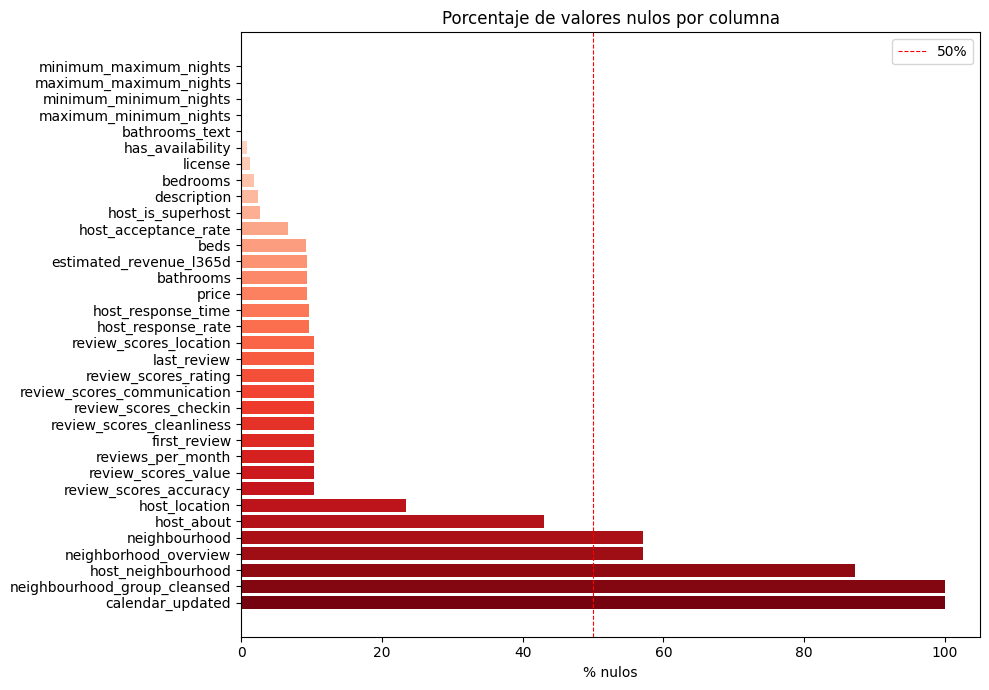


Columnas con >50% nulos (candidatas a eliminar):
                              nulos      %
calendar_updated               9714  100.0
neighbourhood_group_cleansed   9714  100.0
host_neighbourhood             8468   87.2
neighborhood_overview          5544   57.1
neighbourhood                  5544   57.1


In [280]:
# --- Nulos por columna ---
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(1)
null_df = pd.DataFrame({'nulos': nulls, '%': null_pct}).query('nulos > 0').sort_values('%', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(null_df.index, null_df['%'], color=sns.color_palette('Reds_r', len(null_df)))
ax.set_xlabel('% nulos')
ax.set_title('Porcentaje de valores nulos por columna')
ax.axvline(50, color='red', linestyle='--', linewidth=0.8, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nColumnas con >50% nulos (candidatas a eliminar):')
print(null_df[null_df['%'] > 50])

## Variables de alojamiento

In [281]:
np.sum(df['id'].isnull())

np.int64(0)

In [282]:
np.sum(df['listing_url'].isnull())

np.int64(0)

In [283]:
np.sum(df['name'].isnull())

np.int64(0)

In [284]:
np.sum(df['description'].isnull())

np.int64(237)

In [285]:
np.sum(df['property_type'].isnull())

np.int64(0)

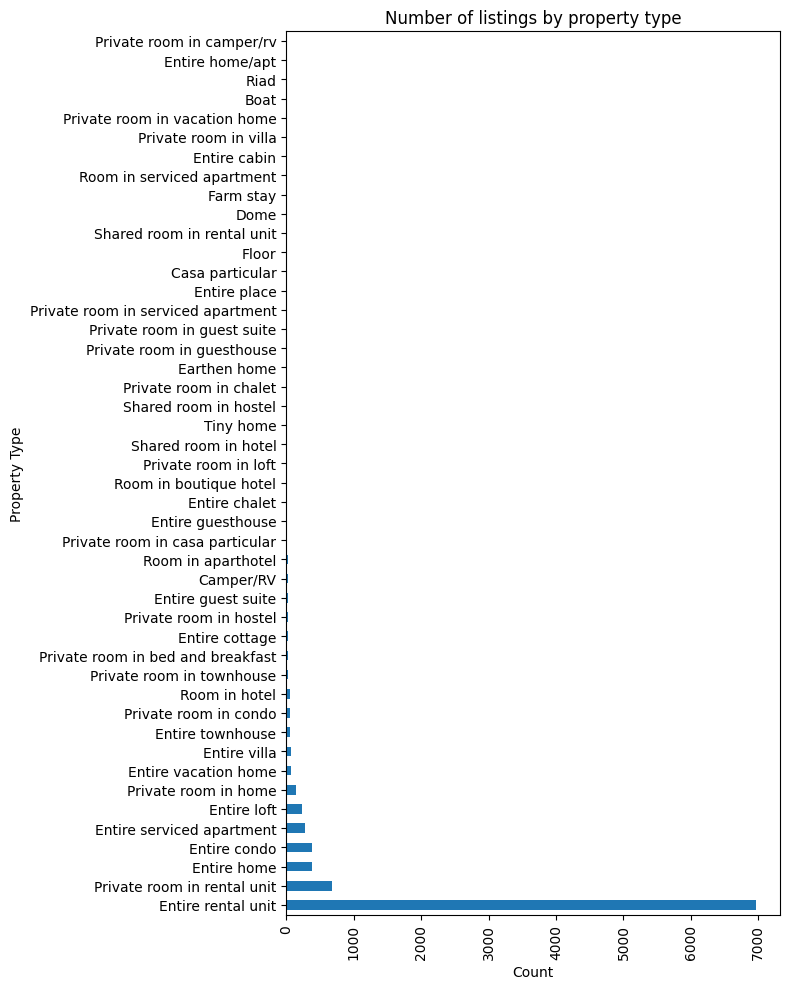

In [286]:
pt_counts = df['property_type'].value_counts()

plt.figure(figsize=(8,10))
pt_counts.plot(kind='barh')

plt.xlabel('Count')
plt.ylabel('Property Type')
plt.title('Number of listings by property type')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [287]:
np.sum(df['room_type'].isnull())

np.int64(0)

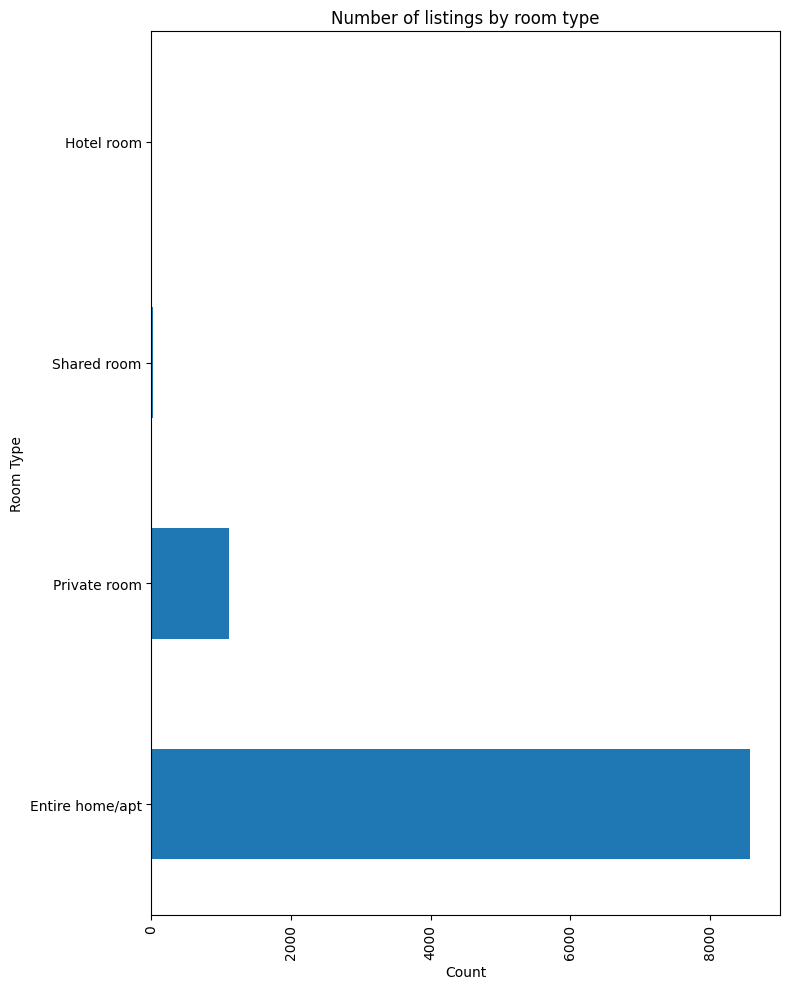

In [288]:
rt_counts = df['room_type'].value_counts()

plt.figure(figsize=(8,10))
rt_counts.plot(kind='barh')

plt.xlabel('Count')
plt.ylabel('Room Type')
plt.title('Number of listings by room type')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Vemos que en la variable `property_type` hay una en español (Casa Particular).

In [289]:
np.sum(df['accommodates'].isnull())

np.int64(0)

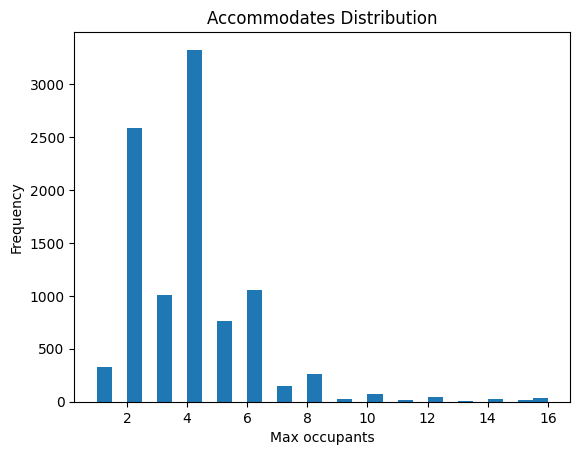

In [290]:
plt.figure()
plt.hist(df['accommodates'], bins=30)

plt.xlabel('Max occupants')
plt.ylabel('Frequency')
plt.title('Accommodates Distribution')

plt.show()

In [291]:
np.sum(df['bathrooms_text'].isnull())

np.int64(5)

In [292]:
df[df['bathrooms_text'].isnull()]['bathrooms']

5150   NaN
6118   NaN
6707   NaN
7229   NaN
7325   NaN
Name: bathrooms, dtype: float64

Tenemos 5 valores faltantes para los baños. Aunque tengamos dos variables para esto, no podemos recuperarlas ya que faltan en ambas variables en los 5 registros.

Podemos relleranlo viendo los anuncios en Airbnb.

In [293]:
df[df['bathrooms_text'].isnull()][['id', 'bathrooms', 'listing_url']]

,id,bathrooms,listing_url
5150,907846578011191658,NaN,https://www.airbnb.com/rooms/907846578011191658
6118,1071778548709501720,NaN,https://www.airbnb.com/rooms/1071778548709501720
6707,1149444780882723841,NaN,https://www.airbnb.com/rooms/1149444780882723841
7229,1199390966969605315,NaN,https://www.airbnb.com/rooms/1199390966969605315
7325,1209436626693592917,NaN,https://www.airbnb.com/rooms/1209436626693592917


- ID: 907846578011191658, baños: 1.
- ID: 1071778548709501720,  baños: 0.
- ID: 1149444780882723841, baños: 0.
- ID: 1199390966969605315, baños: 0.
- ID: 1209436626693592917, baños: 0.

In [294]:
df['bathrooms_text'].unique()

<StringArray>
[           '1 bath',    '2 shared baths',  '1.5 shared baths',
     '1 shared bath',         '1.5 baths',    '1 private bath',
           '2 baths',         '2.5 baths',           '0 baths',
    '3 shared baths',         '4.5 baths',         '3.5 baths',
           '4 baths',           '3 baths',         'Half-bath',
    '0 shared baths',           '5 baths',           '6 baths',
           '7 baths',         '6.5 baths',         '9.5 baths',
  '2.5 shared baths',         '5.5 baths',         '8.5 baths',
                 nan,  'Shared half-bath', 'Private half-bath',
         '7.5 baths',          '16 baths',    '4 shared baths',
           '9 baths']
Length: 31, dtype: str

In [533]:
df['bathroom_shared'] = df['bathrooms_text'].str.contains('shared|compartido', case=False, na=False)

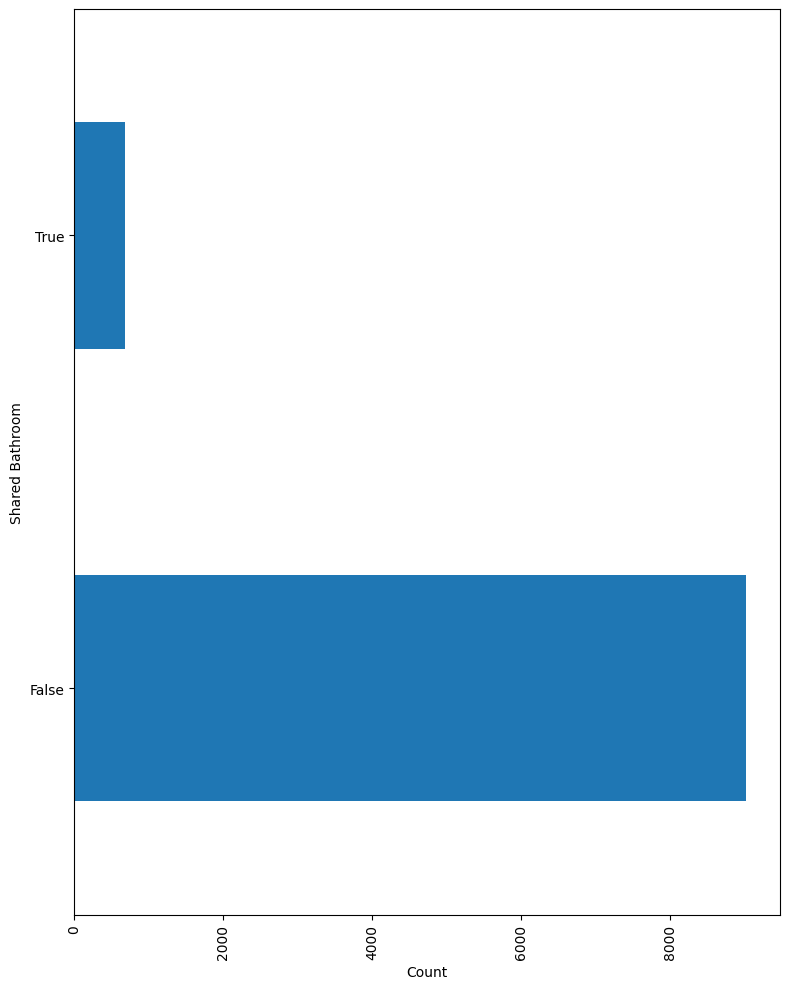

In [535]:
counts = df['bathroom_shared'].value_counts()

plt.figure(figsize=(8,10))
counts.plot(kind='barh')

plt.xlabel('Count')
plt.ylabel('Shared Bathroom')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [295]:
np.sum(df['bedrooms'].isnull())

np.int64(181)

In [296]:
np.sum((df['bedrooms'].isnull()) & ((df['room_type'] != 'Shared room') & (df['room_type'] != 'Private room')))

np.int64(77)

In [297]:
np.sum((df['bedrooms'].isnull() & df['beds'].isnull()))

np.int64(167)

In [298]:
np.sum((df['bedrooms'].isnull()) & (df['beds'] > 1))

np.int64(9)

In [299]:
df[(df['bedrooms'].isnull()) & (df['beds'] > 1) & (df['room_type'] != 'Shared room')]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
6147,1077483325589081183,https://www.airbnb.com/rooms/1077483325589081183,20250930030808,2025-09-30,city scrape,Estudios Larios 9,"Located in Malaga, the studio apartment Estudi...",NaN,https://a0.muscache.com/pictures/prohost-api/H...,549699849,...,4.6,5.0,4.2,VFT/MA/70306,t,7,7,0,0,0.25
6457,1117251465289739025,https://www.airbnb.com/rooms/1117251465289739025,20250930030808,2025-09-30,city scrape,Gorgeous apartment in Málaga with WiFi,NaN,"City: 10 m, Shops: 20 m, Restaurants: 20 m, Be...",https://a0.muscache.com/pictures/prohost-api/H...,141547098,...,3.0,3.0,1.0,VUT/MA/79619,t,1,1,0,0,0.07
8699,1387426709965584505,https://www.airbnb.com/rooms/1387426709965584505,20250930030808,2025-09-30,city scrape,Komfortables Ferienstudio mit weitläufiger.,NaN,"Motorway: 1.5 km, Sea: 3.0 km, Centre (village...",https://a0.muscache.com/pictures/prohost-api/H...,685495832,...,NaN,NaN,NaN,VFT/MA/-08407,f,3,3,0,0,NaN
9611,1501329478527925393,https://www.airbnb.com/rooms/1501329478527925393,20250930030808,2025-09-30,city scrape,Modern Loft in Málaga,"Located in Málaga, this modern 40 sqm apartmen...",NaN,https://a0.muscache.com/pictures/prohost-api/H...,702996668,...,NaN,NaN,NaN,ESFCTU0000290220003629760000000000000000VFT/MA...,t,9,9,0,0,NaN


In [300]:
df[df['room_type'] == 'Shared room']['bedrooms'].unique()

array([nan,  1.,  0.])

In [301]:
df[df['bedrooms'].isnull()]['beds'].unique()

array([nan,  1.,  2.,  4.,  8., 16.])

In [302]:
df[(df['bedrooms'].isnull()) & (df['description'].isnull())]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
2742,49201739,https://www.airbnb.com/rooms/49201739,20250930030808,2025-09-30,previous scrape,APARTAMENTO ESTUDIO NUEVO EN EL CENTRO DE MÁLAGA,NaN,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,304620562,...,4.74,4.67,4.52,VFT/MA/45101,t,2,2,0,0,0.50
3566,597073785697421497,https://www.airbnb.com/rooms/597073785697421497,20250930030808,2025-09-30,previous scrape,Estudio a un paso del casco histórico,NaN,Old quarter of the city of Malaga known as El ...,https://a0.muscache.com/pictures/f3f9b1ea-286e...,44662538,...,4.97,4.53,4.65,VFT/MA/45877,f,3,3,0,0,2.23
6457,1117251465289739025,https://www.airbnb.com/rooms/1117251465289739025,20250930030808,2025-09-30,city scrape,Gorgeous apartment in Málaga with WiFi,NaN,"City: 10 m, Shops: 20 m, Restaurants: 20 m, Be...",https://a0.muscache.com/pictures/prohost-api/H...,141547098,...,3.00,3.00,1.00,VUT/MA/79619,t,1,1,0,0,0.07
8699,1387426709965584505,https://www.airbnb.com/rooms/1387426709965584505,20250930030808,2025-09-30,city scrape,Komfortables Ferienstudio mit weitläufiger.,NaN,"Motorway: 1.5 km, Sea: 3.0 km, Centre (village...",https://a0.muscache.com/pictures/prohost-api/H...,685495832,...,NaN,NaN,NaN,VFT/MA/-08407,f,3,3,0,0,NaN


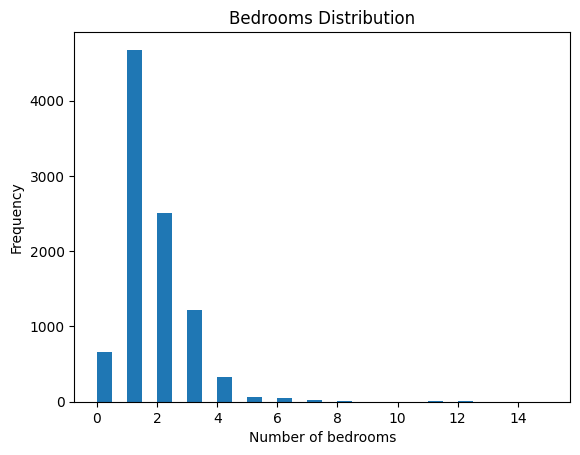

In [303]:
plt.figure()
plt.hist(df['bedrooms'], bins=30)

plt.xlabel('Number of bedrooms')
plt.ylabel('Frequency')
plt.title('Bedrooms Distribution')

plt.show()

In [304]:
np.sum(df['beds'].isnull())

np.int64(894)

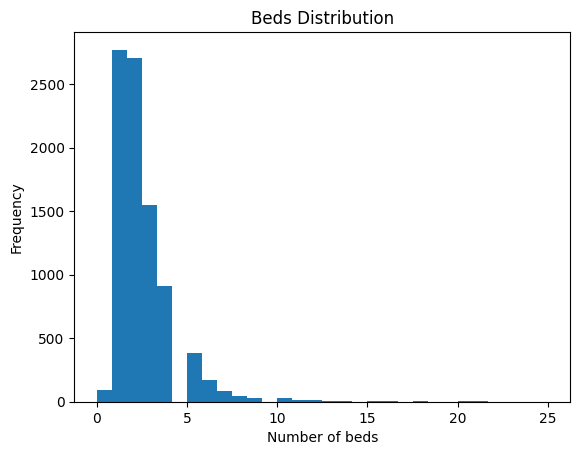

In [305]:
plt.figure()
plt.hist(df['beds'], bins=30)

plt.xlabel('Number of beds')
plt.ylabel('Frequency')
plt.title('Beds Distribution')

plt.show()

Podemos ver los valores más extremos.

In [306]:
df[df['beds'] > 20]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
927,21010639,https://www.airbnb.com/rooms/21010639,20250930030808,2025-09-30,city scrape,Villa Las Yedras. Malaga city,"Ideal for families, sports teams, cohabitation...","Our ""Villa Las Yedras"" is located in the city ...",https://a0.muscache.com/pictures/hosting/Hosti...,151284285,...,4.89,4.67,4.76,ESFCTU0000290200004921360000000000000000VFT/MA...,f,1,1,0,0,1.18
2773,49550107,https://www.airbnb.com/rooms/49550107,20250930030808,2025-09-30,city scrape,Lovely home in Málaga,This beautiful vacation home is in an excellen...,"City: 100 m, Restaurants: 1.0 km, Shops: 1.0 k...",https://a0.muscache.com/pictures/prohost-api/H...,153921150,...,4.38,4.88,4.50,VUT/MA/16709,t,1,1,0,0,0.24
4795,843171583208123899,https://www.airbnb.com/rooms/843171583208123899,20250930030808,2025-09-30,city scrape,Groups 12 Bedrooms 3 Bathrooms PEÑA st. 1km Beach,Very central set of 3 apartments in Calle PEÑA...,NaN,https://a0.muscache.com/pictures/307288de-64c5...,329266025,...,4.67,5.00,4.33,VFT/MA/47227,f,27,21,6,0,0.11
8232,1322878490516135755,https://www.airbnb.com/rooms/1322878490516135755,20250930030808,2025-09-30,city scrape,Groups 12 Bedrooms 3 Bathrooms PEÑA st. 1km Beach,Set of 3 very central apartments in Calle PEÑA...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,422332697,...,NaN,NaN,NaN,VUT/MA/47227,f,26,9,17,0,NaN


In [307]:
np.sum(df['amenities'].isnull())

np.int64(0)

In [308]:
(df['amenities'].apply(lambda x: len(x.split(',')) if isinstance(x, str) else 0))

0       51
1       21
2       56
3       52
4       38
        ..
9709     7
9710    11
9711    26
9712    27
9713    29
Name: amenities, Length: 9714, dtype: int64

In [309]:
df['amenities_count'] = df['amenities'].apply(lambda x: len(x.split(',')) if isinstance(x, str) else 0)

In [310]:
np.sum(df['amenities_count'].isnull())

np.int64(0)

Verificamos con las URLs que si tienen ese número tan grande de camas.

In [311]:
np.sum(df['price'].isnull())

np.int64(899)

In [312]:
df['price_num'] = (df['price']
                   .str.replace(r'[\$,]', '', regex=True)
                   .astype(float))

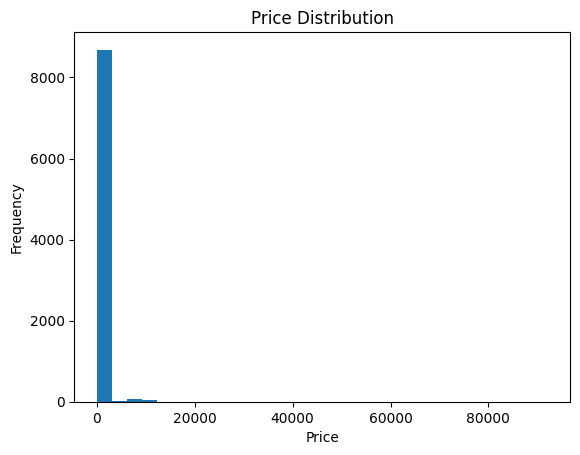

In [313]:
plt.figure()
plt.hist(df['price_num'], bins=30)

plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution')

plt.show()

Parece haber algun outlier.

In [314]:
df[df['price_num'] > 20000]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,amenities_count,price_num
2629,47444051,https://www.airbnb.com/rooms/47444051,20250930030808,2025-09-30,city scrape,Teatro Romano 2,The apartment is located in the center of Mala...,The neighborhood is ideal for getting to know ...,https://a0.muscache.com/pictures/miso/Hosting-...,383001067,...,4.83,ESFCTU0000290200007573890000000000000000VFT/MA...,t,2,2,0,0,2.85,42,21911.0
5152,908030524200905295,https://www.airbnb.com/rooms/908030524200905295,20250930030808,2025-09-30,city scrape,Habitación centro Málaga,Accommodation located 10 minutes from downtown...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,310365480,...,4.20,Exempt,f,1,0,1,0,0.18,30,92150.0


El anuncio con un precio superior a 90.000 euros es real, verificando el enlace de la URL. Aunque podría ser un error del anfritión.

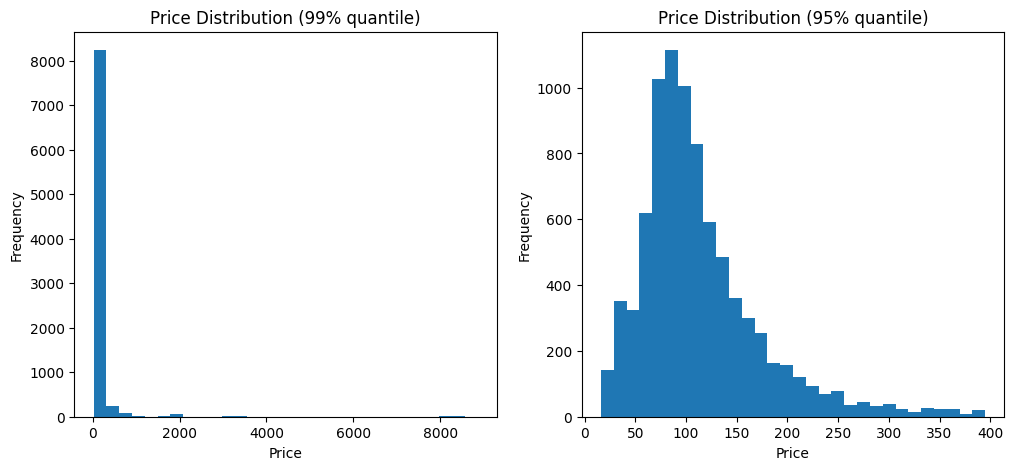

In [315]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df[df['price_num'] < df['price_num'].quantile(0.99)]['price_num'], bins=30)

plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution (99% quantile)')

plt.subplot(1,2,2)
plt.hist(df[df['price_num'] < df['price_num'].quantile(0.95)]['price_num'], bins=30)

plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution (95% quantile)')

plt.show()

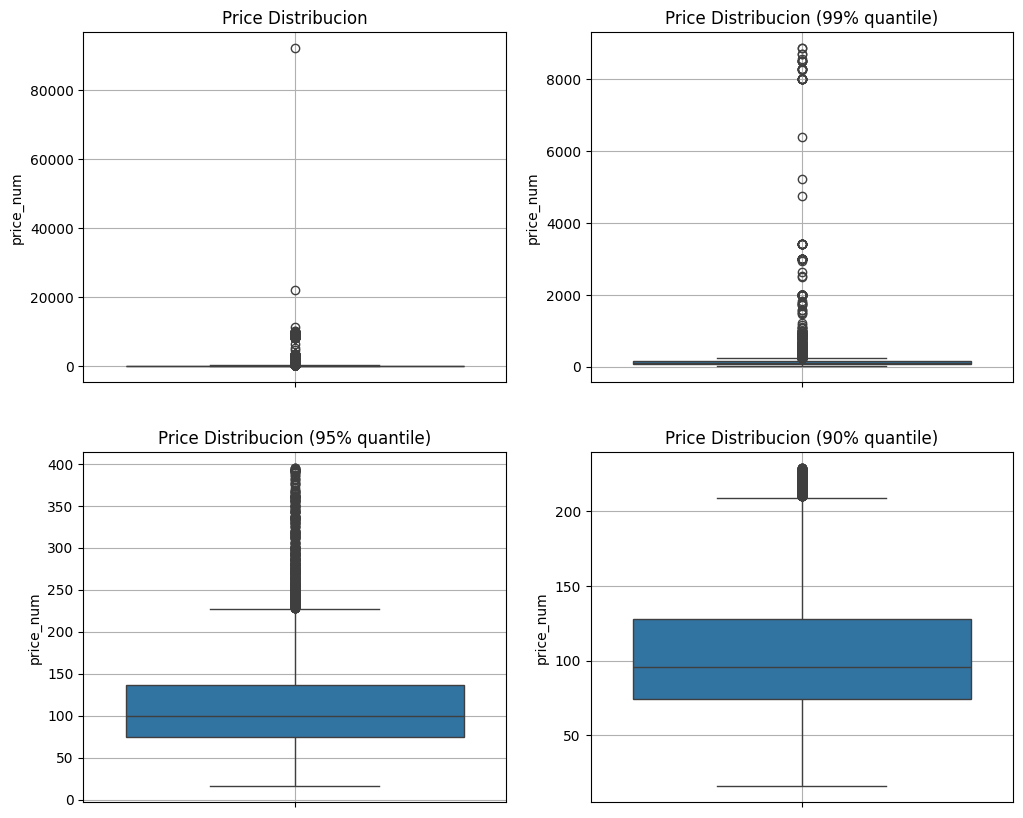

In [316]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.boxplot(df['price_num'])
plt.title('Price Distribucion')
plt.grid(True)

plt.subplot(2,2,2)
sns.boxplot(df[df['price_num'] < df['price_num'].quantile(0.99)]['price_num'])
plt.title('Price Distribucion (99% quantile)')
plt.grid(True)

plt.subplot(2,2,3)
sns.boxplot(df[df['price_num'] < df['price_num'].quantile(0.95)]['price_num'])
plt.title('Price Distribucion (95% quantile)')
plt.grid(True)

plt.subplot(2,2,4)
sns.boxplot(df[df['price_num'] < df['price_num'].quantile(0.9)]['price_num'])
plt.title('Price Distribucion (90% quantile)')
plt.grid(True)

plt.show()

In [317]:
print(df[(df['price_num'] < 15000) & (df['price_num'] > 250)]['price_num'].min())
print(df[(df['price_num'] < 15000) & (df['price_num'] > 250)]['price_num'].max())

251.0
11412.0


<Axes: >

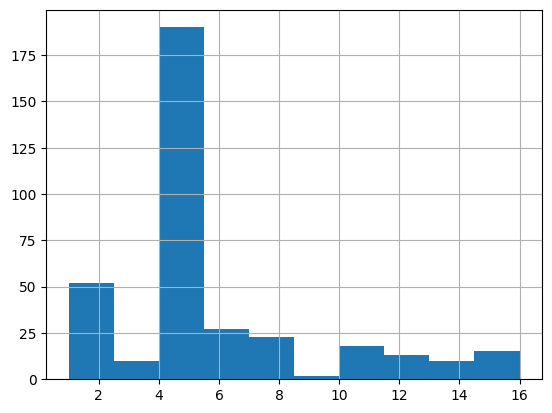

In [318]:
(df[(df['price_num'] < 15000) & (df['price_num'] > 500)]['accommodates']).hist()

In [319]:
(df[(df['price_num'] < 15000) & (df['price_num'] > 250)]['accommodates']).max()

np.int64(16)

**Conclusiones más importantes**:
* 237 valores nulos de `description`. No hacemos nada respecto a esto. Preparar esta variable para procesamiento con PLN (tokenización, lematización...)
* La variable `property_type` tiene muchas categorías como para codificar con OHE. Considerar eliminar esta variable, ya que tenemos la variable `room_type` con la misma información pero más genérica (4 categorías). Si dejamos esta variable, hay que tener cuidado con una categoría que está en español.
* Usar la variable `bathrooms_text` para imputar los valores faltantes de `bathrooms` y crear la variable `shared_bathroom` (si el baño es compartido o no). Una vez usemos esta variable, eliminarla. También tenemos cinco anuncios con valores faltantes en `bathrooms_text`. Verificando el número de baños en la URL de los anuncios, sacamos la siguiente información para imputar:
    * ID: 907846578011191658, baños: 1.
    * ID: 1071778548709501720,  baños: 0.
    * ID: 1149444780882723841, baños: 0.
    * ID: 1199390966969605315, baños: 0.
    * ID: 1209436626693592917, baños: 0.
* Tenemos 181 valores nulos en la variable `bedrooms`. Primero, verificamos con `room_type` si son *Private room* o *Shared room*, pondremos una habitación. Sino, imputaremos la mediana agrupando por la variable `accommodates`.
* 894 valores nulos en la variable `beds`. Al igual que antes, imputamos la mediana agrupando por `accomodates`.
* Creación de nueva variable `amenities_count`, siendo el número de servicios que ofrece el Airbnb.
* Procesamiento de variable `amenities` con ORJSON y ULTRAJSON, mejorando la eficacia de leer JSON de esta variable.
* Valores muy extremos del precio. Consideramos una transformación logarítmica o *zipf* para caracterizar la bajada rápida y valores extremos.

## Variables de anfritión

In [320]:
np.sum(df['host_id'].isnull())

np.int64(0)

In [321]:
df['host_id'].nunique()

3504

In [322]:
np.sum(df['host_name'].isnull())

np.int64(0)

In [323]:
(df.groupby('host_id')['host_name'].nunique() > 1).any()

np.False_

In [324]:
np.sum(df['host_since'].isnull())

np.int64(0)

In [325]:
df['host_since'] = pd.to_datetime(df['host_since'])

In [326]:
df['host_since'].head(5)

0   2011-04-15
1   2011-07-08
2   2012-02-02
3   2012-02-09
4   2011-12-22
Name: host_since, dtype: datetime64[us]

<Axes: >

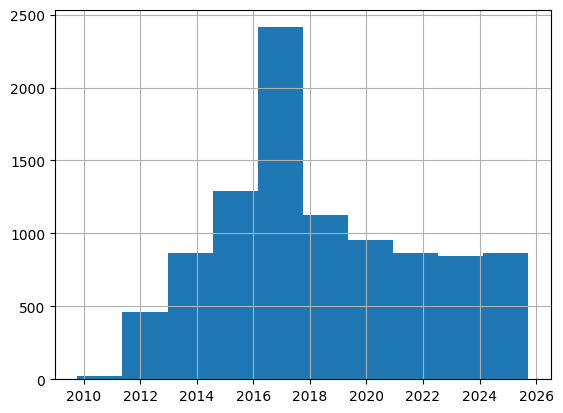

In [327]:
df['host_since'].hist()

In [328]:
np.sum(df['host_is_superhost'].isnull())

np.int64(265)

In [329]:
df['host_response_rate']

0       100%
1       100%
2        91%
3       100%
4        86%
        ... 
9709     80%
9710     80%
9711    100%
9712    100%
9713    100%
Name: host_response_rate, Length: 9714, dtype: str

In [330]:
df['host_acceptance_rate'] = df['host_acceptance_rate'].str.replace('%', '')
df['host_response_rate'] = df['host_response_rate'].str.replace('%', '')

df['host_acceptance_rate'] = pd.to_numeric(df['host_acceptance_rate'], errors='coerce')
df['host_response_rate'] = pd.to_numeric(df['host_response_rate'], errors='coerce')

In [331]:
len(df[
    (df['host_is_superhost'].isnull()) &
    (df['host_acceptance_rate'] > 99) &
    (df['host_response_rate'] >= 90) &
    (df['review_scores_rating'] >= 4.8) &
    (df['number_of_reviews'] >= 10)
])

35

In [332]:
len(df[
    ((df['host_is_superhost'].isnull())) &
    ((df['host_acceptance_rate'] <= 99) |
    (df['host_response_rate'] < 90) |
    (df['review_scores_rating'] < 4.8) |
    (df['number_of_reviews'] < 10))
])

229

In [333]:
np.sum(
    (df['host_is_superhost'].isnull()) &
    (
        (df['host_acceptance_rate'].isnull()) |
        (df['host_response_rate'].isnull()) |
        (df['review_scores_rating'].isnull()) |
        (df['number_of_reviews'].isnull())
    )
)

np.int64(23)

In [334]:
np.sum(
    (
        (df['host_is_superhost'].isnull()) &
        
        (
            (df['host_acceptance_rate'].isnull()) |
            (df['host_response_rate'].isnull()) |
            (df['review_scores_rating'].isnull()) |
            (df['number_of_reviews'].isnull())
        )
    ) &
    (
        (df['host_is_superhost'].isnull()) &
        (
            (df['host_acceptance_rate'] <= 99) |
            (df['host_response_rate'] < 90) |
            (df['review_scores_rating'] < 4.8) |
            (df['number_of_reviews'] < 10)
        )
    )
)

np.int64(22)

In [335]:
np.sum(
    ~
    (
        (df['host_is_superhost'].isnull()) &
        
        (
            (df['host_acceptance_rate'].isnull()) |
            (df['host_response_rate'].isnull()) |
            (df['review_scores_rating'].isnull()) |
            (df['number_of_reviews'].isnull())
        )
    ) &
    (
        (df['host_is_superhost'].isnull()) &
        (
            (df['host_acceptance_rate'] <= 99) |
            (df['host_response_rate'] < 90) |
            (df['review_scores_rating'] < 4.8) |
            (df['number_of_reviews'] < 10)
        )
    )
)

np.int64(207)

In [336]:
S = df['host_is_superhost'].isnull()

M = (
    df['host_acceptance_rate'].isnull() |
    df['host_response_rate'].isnull() |
    df['review_scores_rating'].isnull() |
    df['number_of_reviews'].isnull()
)

L = (
    (df['host_acceptance_rate'] <= 99) |
    (df['host_response_rate'] < 90) |
    (df['review_scores_rating'] < 4.8) |
    (df['number_of_reviews'] < 10)
)

# Solo missing info “puros”, que no podemos decidir
true_missing = S & M & ~L

df[true_missing][['host_acceptance_rate', 'host_response_rate', 'review_scores_rating', 'number_of_reviews', 'listing_url']]

,host_acceptance_rate,host_response_rate,review_scores_rating,number_of_reviews,listing_url
3652,NaN,NaN,4.85,121,https://www.airbnb.com/rooms/619610850536528144


In [337]:
df[df['host_id'].isin(df[true_missing]['host_id'])]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,amenities_count,price_num
3652,619610850536528144,https://www.airbnb.com/rooms/619610850536528144,20250930030808,2025-09-30,city scrape,Habitación en Málaga - chambre,Room with Double Beds.<br />With a lock on the...,Camino de Suárez is a very lively neighborhood...,https://a0.muscache.com/pictures/hosting/Hosti...,474946836,...,4.83,VFT/MA/52511,f,1,0,1,0,2.95,25,29.0


In [338]:
df['host_is_superhost']

0       t
1       t
2       f
3       f
4       f
       ..
9709    f
9710    f
9711    f
9712    f
9713    f
Name: host_is_superhost, Length: 9714, dtype: str

In [339]:
df.loc[
    (df['host_is_superhost'].isnull()) &
    (df['host_acceptance_rate'] > 99) &
    (df['host_response_rate'] >= 90) &
    (df['review_scores_rating'] >= 4.8) &
    (df['number_of_reviews'] >= 10),
    'host_is_superhost'
] = 't'

In [340]:
df.loc[true_missing, 'host_is_superhost'] = 't'

In [341]:
df.loc[
    ((df['host_is_superhost'].isnull())) &
    ((df['host_acceptance_rate'] <= 99) |
    (df['host_response_rate'] < 90) |
    (df['review_scores_rating'] < 4.8) |
    (df['number_of_reviews'] < 10)),
    'host_is_superhost'
] = 'f'

In [342]:
np.sum(df['host_is_superhost'].isnull())

np.int64(0)

In [343]:
df['host_is_superhost'] = df['host_is_superhost'] == 't'

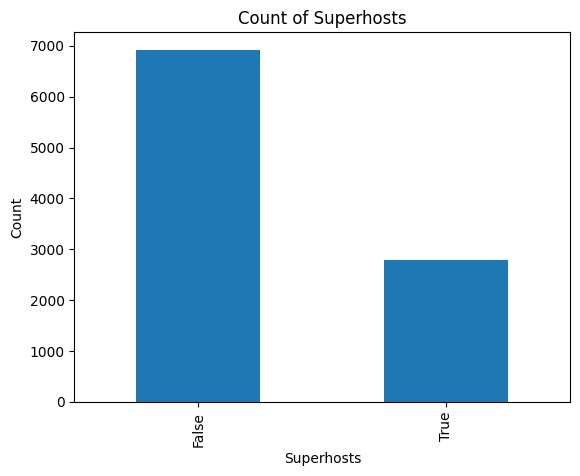

In [344]:
counts = df['host_is_superhost'].value_counts()

counts.plot(kind='bar')
plt.xlabel('Superhosts')
plt.ylabel('Count')
plt.title('Count of Superhosts')
plt.show()

In [345]:
df['host_identity_verified']

0       t
1       t
2       t
3       t
4       t
       ..
9709    t
9710    t
9711    f
9712    f
9713    t
Name: host_identity_verified, Length: 9714, dtype: str

In [346]:
np.sum(df['host_identity_verified'].isnull())

np.int64(0)

In [347]:
df['host_identity_verified'] = df['host_identity_verified'] == 't'

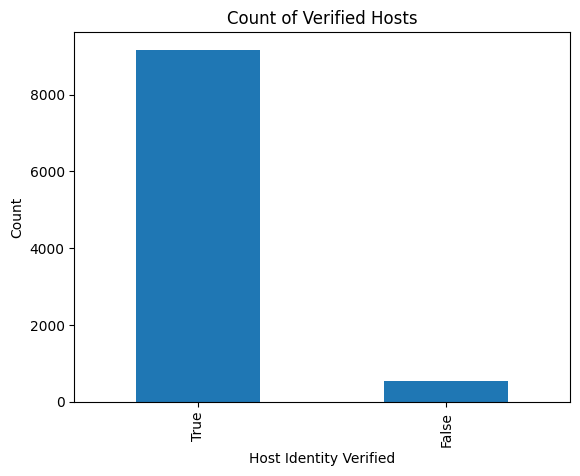

In [348]:
counts = df['host_identity_verified'].value_counts()

counts.plot(kind='bar')
plt.xlabel('Host Identity Verified')
plt.ylabel('Count')
plt.title('Count of Verified Hosts')
plt.show()

In [349]:
df['host_response_time'].unique()

<StringArray>
[    'within an hour',       'within a day', 'within a few hours',
                  nan, 'a few days or more']
Length: 5, dtype: str

In [350]:
np.sum(df['host_response_time'].isnull())

np.int64(929)

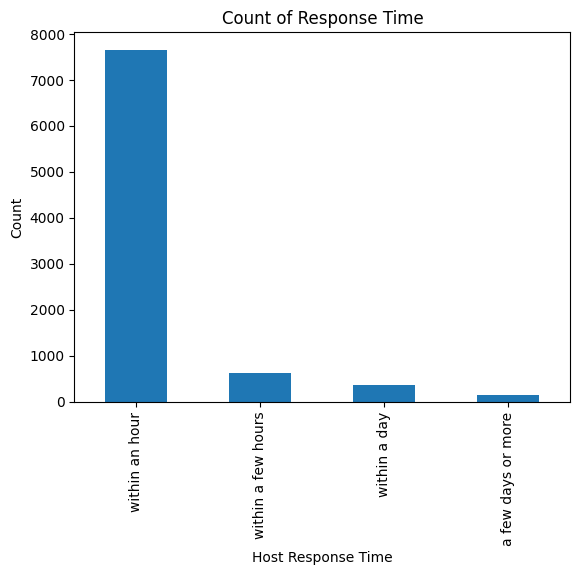

In [351]:
counts = df['host_response_time'].value_counts()

counts.plot(kind='bar')
plt.xlabel('Host Response Time')
plt.ylabel('Count')
plt.title('Count of Response Time')
plt.show()

In [352]:
ids_response_na = df[df['host_response_time'].isnull()]['host_id']

df[
    (df['host_id'].isin(ids_response_na)) &
    (~df['host_response_time'].isnull())
]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,amenities_count,price_num


In [353]:
modes = df.groupby('host_is_superhost')['host_response_time'] \
                   .agg(lambda x: x.mode().iloc[0])
modes

host_is_superhost
False    within an hour
True     within an hour
Name: host_response_time, dtype: str

In [354]:
def imputar(row):
    if pd.isnull(row['host_response_time']):
        mode = modes[row['host_is_superhost']]
        return mode
    else:
        return row['host_response_time']

In [355]:
df['host_response_time'] = df.apply(imputar, axis=1)

In [356]:
np.sum(df['host_response_time'].isnull())

np.int64(0)

In [357]:
np.sum(
    df['host_acceptance_rate'].isnull()
)

np.int64(643)

In [358]:
ids_response_na = df[df['host_acceptance_rate'].isnull()]['host_id']

df[
    (df['host_id'].isin(ids_response_na)) &
    (~df['host_acceptance_rate'].isnull())
]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,amenities_count,price_num


<Axes: >

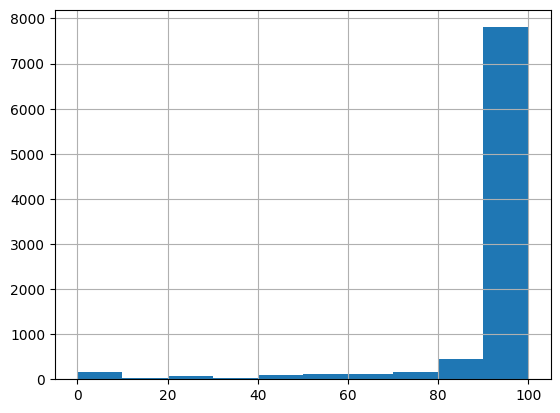

In [359]:
df['host_acceptance_rate'].hist()

In [360]:
np.sum(
    (df['host_acceptance_rate'].isnull()) &
    (df['host_is_superhost'])
)

np.int64(3)

In [361]:
np.sum(
    (df['host_acceptance_rate'].isnull()) &
    (~df['host_is_superhost'])
)

np.int64(640)

In [362]:
medians = df.groupby('host_is_superhost')['host_acceptance_rate'].median()
medians

host_is_superhost
False    100.0
True     100.0
Name: host_acceptance_rate, dtype: float64

In [363]:
def imputar_con_ruido(row, std=5):
    if pd.isnull(row['host_acceptance_rate']):
        median = medians[row['host_is_superhost']]
        value = median + np.random.normal(0, std)
        value = value.clip(0, 100)
        return value
    else:
        return row['host_acceptance_rate']

In [364]:
df['host_acceptance_rate'] = df.apply(imputar_con_ruido, axis=1)

In [365]:
np.sum(df['host_acceptance_rate'].isnull())

np.int64(0)

<Axes: >

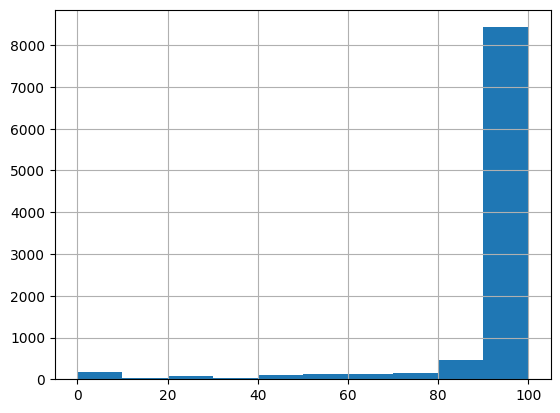

In [366]:
df['host_acceptance_rate'].hist()

In [367]:
np.sum(df['host_response_rate'].isnull())

np.int64(929)

<Axes: >

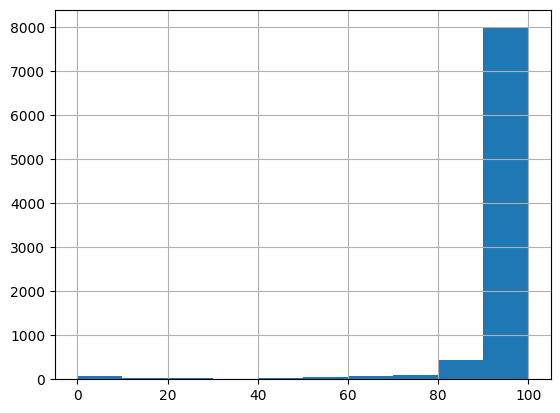

In [368]:
df['host_response_rate'].hist()

In [369]:
medians = df.groupby(['host_is_superhost', 'host_response_time'])['host_response_rate'].median()
medians

host_is_superhost  host_response_time
False              a few days or more      0.0
                   within a day           88.0
                   within a few hours     99.0
                   within an hour        100.0
True               a few days or more     20.0
                   within a day          100.0
                   within a few hours    100.0
                   within an hour        100.0
Name: host_response_rate, dtype: float64

In [370]:
def imputar_con_ruido(row, std=5):
    if pd.isnull(row['host_response_rate']):
        median = medians[(row['host_is_superhost'], row['host_response_time'])]
        value = median + np.random.normal(0, std)
        value = value.clip(0, 100)
        return value
    else:
        return row['host_response_rate']

In [371]:
df['host_response_rate'] = df.apply(imputar_con_ruido, axis=1)

In [372]:
np.sum(df['host_response_rate'].isnull())

np.int64(0)

<Axes: >

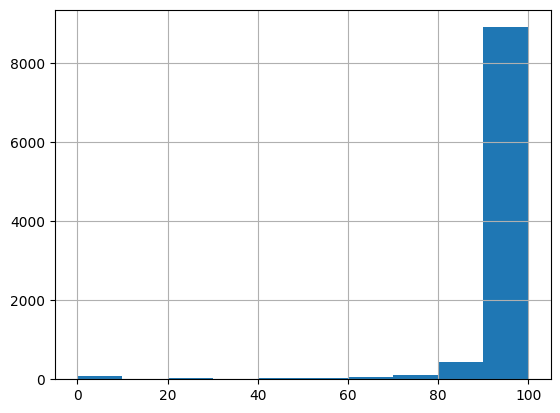

In [373]:
df['host_response_rate'].hist()

In [374]:
np.sum(df['host_response_rate'].isnull())

np.int64(0)

In [375]:
np.sum(df['host_listings_count'].isnull())

np.int64(0)

<Axes: >

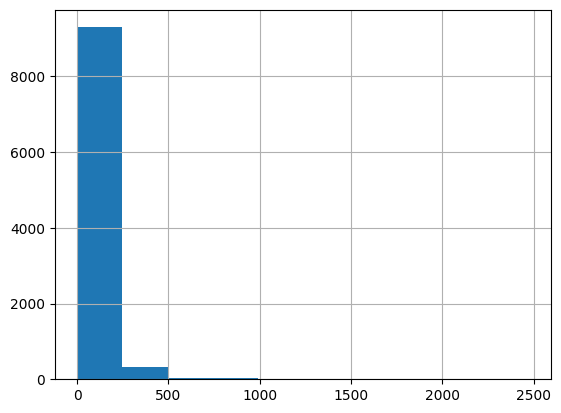

In [376]:
df['host_listings_count'].hist()

<Axes: >

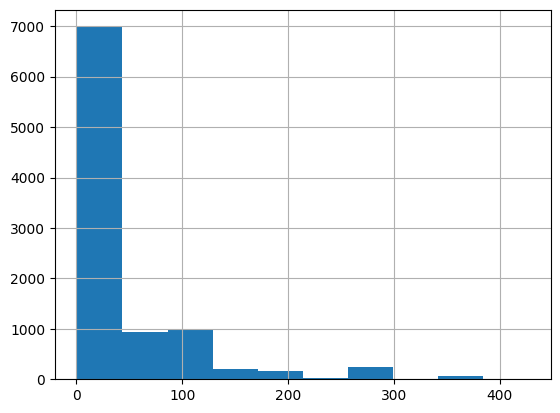

In [377]:
df[df['host_listings_count'] < df['host_listings_count'].quantile(0.99)]['host_listings_count'].hist()

In [378]:
(df.groupby('host_id')['host_listings_count'].nunique() > 1).any()

np.False_

In [379]:
df[df['host_listings_count'] > 500]['host_id'].unique()

array([392227252, 418270816,  80839530, 438136382, 439074505, 579350840,
       270230553, 587006009, 657440161, 674120741, 685495832, 686781509,
       702996668, 695641295])

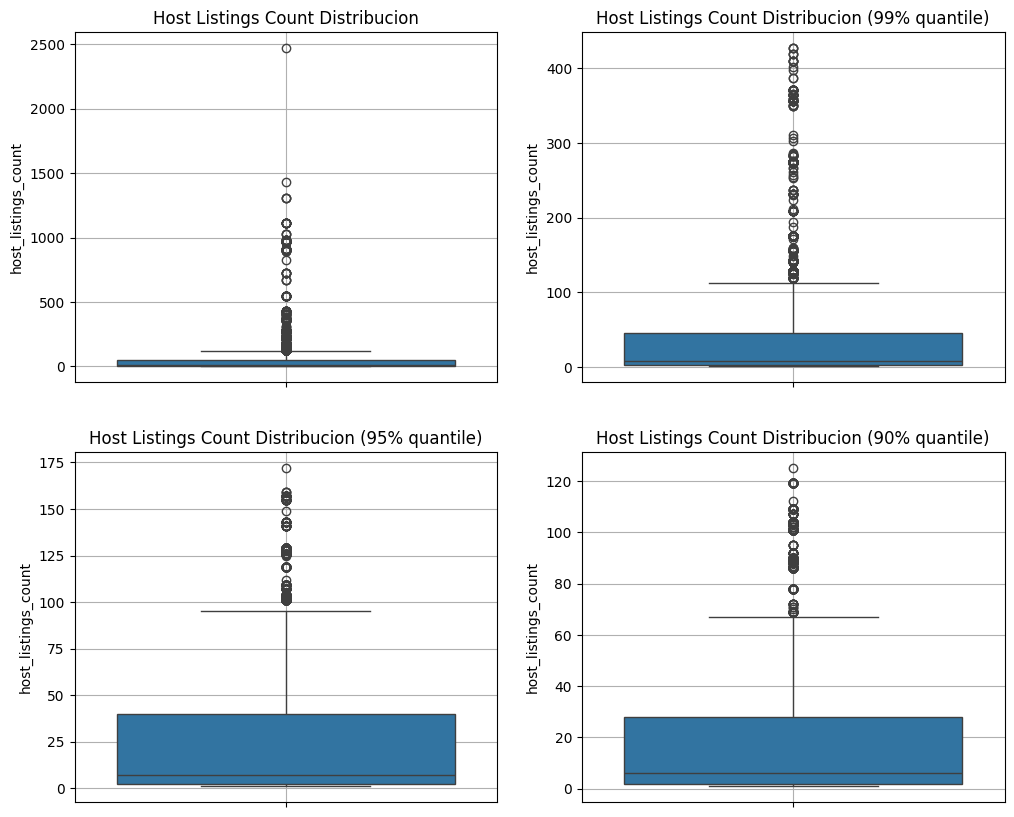

In [380]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.boxplot(df['host_listings_count'])
plt.title('Host Listings Count Distribucion')
plt.grid(True)

plt.subplot(2,2,2)
sns.boxplot(df[df['host_listings_count'] < df['host_listings_count'].quantile(0.99)]['host_listings_count'])
plt.title('Host Listings Count Distribucion (99% quantile)')
plt.grid(True)

plt.subplot(2,2,3)
sns.boxplot(df[df['host_listings_count'] < df['host_listings_count'].quantile(0.95)]['host_listings_count'])
plt.title('Host Listings Count Distribucion (95% quantile)')
plt.grid(True)

plt.subplot(2,2,4)
sns.boxplot(df[df['host_listings_count'] < df['host_listings_count'].quantile(0.9)]['host_listings_count'])
plt.title('Host Listings Count Distribucion (90% quantile)')
plt.grid(True)

plt.show()

In [381]:
df[df['host_listings_count'] > 2000]['host_total_listings_count']

9678    3365
Name: host_total_listings_count, dtype: int64

In [382]:
calculated_listings_dataset = df.groupby('host_id').size()
calculated_listings_dataset

host_id
45553        1
102117       1
112673       1
224925       1
252529       2
            ..
719118226    1
719490269    1
719627643    1
720270848    1
720299095    1
Length: 3504, dtype: int64

In [383]:
df['calculated_count'] = df['host_id'].map(calculated_listings_dataset)

len(df[df['host_listings_count'] == df['calculated_count']]['host_id'].unique())

2597

<Axes: >

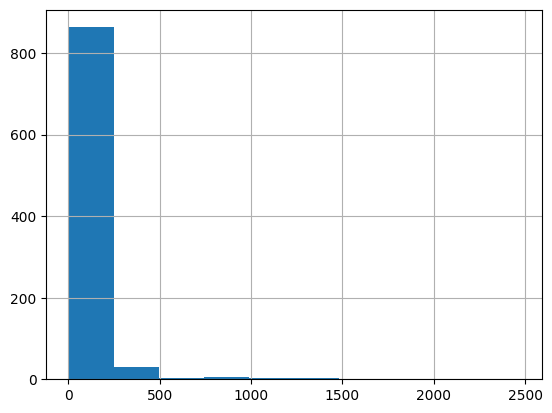

In [384]:
df['diff'] = df['host_listings_count'] - df['calculated_count']

diff = df[df['diff'] != 0][['host_id', 'diff']].drop_duplicates('host_id')

diff['diff'].hist()

In [385]:
hosts = df.groupby('host_id').first()
diff = hosts['host_listings_count'] - hosts['calculated_count'] 
(diff != 0).sum()

np.int64(907)

In [386]:
np.sum(df['host_total_listings_count'].isnull())

np.int64(0)

In [387]:
(df['host_total_listings_count'] >= df['host_listings_count']).all()

np.True_

<Axes: >

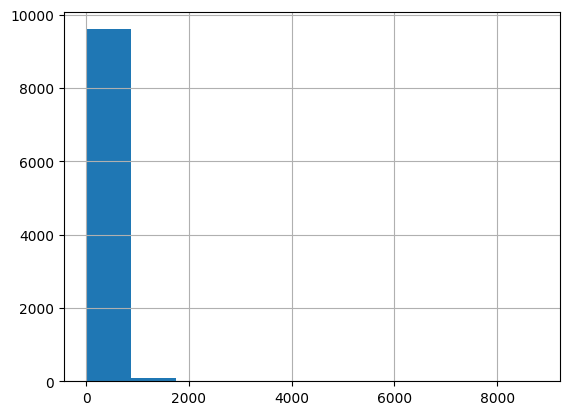

In [388]:
df['host_total_listings_count'].hist()

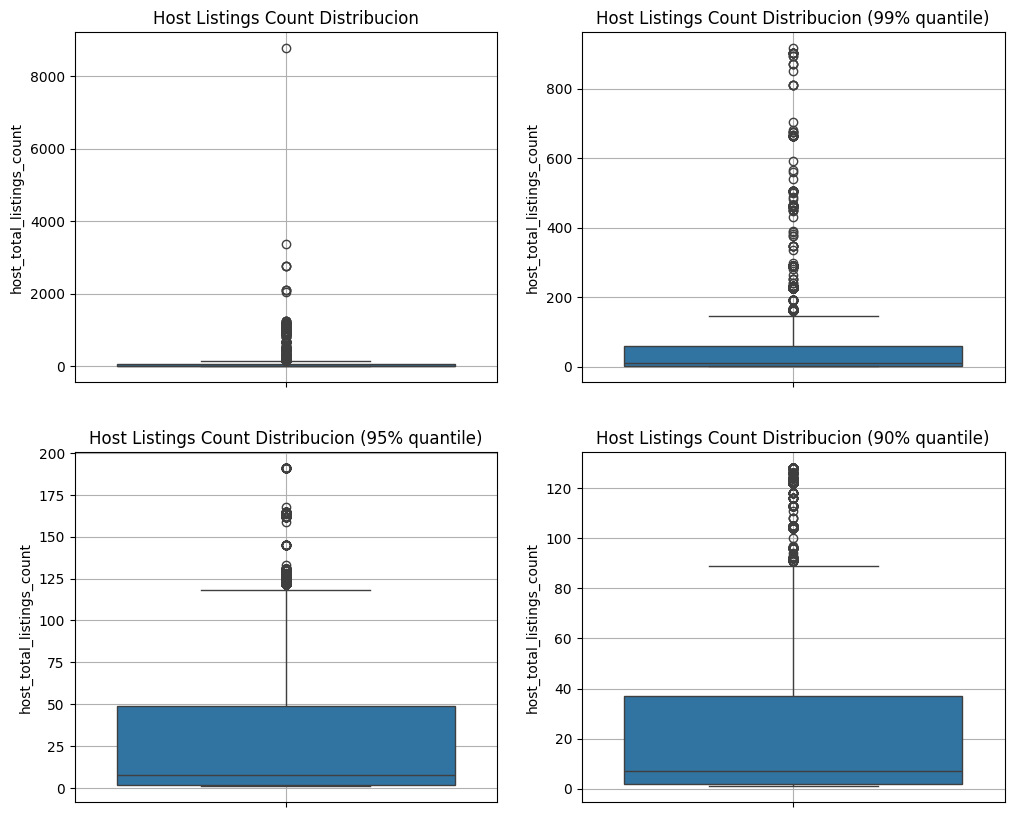

In [389]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.boxplot(df['host_total_listings_count'])
plt.title('Host Listings Count Distribucion')
plt.grid(True)

plt.subplot(2,2,2)
sns.boxplot(df[df['host_total_listings_count'] < df['host_total_listings_count'].quantile(0.99)]['host_total_listings_count'])
plt.title('Host Listings Count Distribucion (99% quantile)')
plt.grid(True)

plt.subplot(2,2,3)
sns.boxplot(df[df['host_total_listings_count'] < df['host_total_listings_count'].quantile(0.95)]['host_total_listings_count'])
plt.title('Host Listings Count Distribucion (95% quantile)')
plt.grid(True)

plt.subplot(2,2,4)
sns.boxplot(df[df['host_total_listings_count'] < df['host_total_listings_count'].quantile(0.9)]['host_total_listings_count'])
plt.title('Host Listings Count Distribucion (90% quantile)')
plt.grid(True)

plt.show()

In [390]:
np.sum(df['host_verifications'].isnull())

np.int64(0)

In [391]:
df['host_verifications']

0                     ['email', 'phone']
1                     ['email', 'phone']
2                     ['email', 'phone']
3                     ['email', 'phone']
4       ['email', 'phone', 'work_email']
                      ...               
9709                  ['email', 'phone']
9710                  ['email', 'phone']
9711                  ['email', 'phone']
9712                  ['email', 'phone']
9713                  ['email', 'phone']
Name: host_verifications, Length: 9714, dtype: str

In [392]:
df['host_verifications_ast'] = df['host_verifications'].apply(ast.literal_eval)

In [393]:
all_values = df['host_verifications'].explode()
all_values.unique()

<StringArray>
[                '['email', 'phone']',   '['email', 'phone', 'work_email']',
                          '['phone']',                          '['email']',
            '['phone', 'work_email']', '['email', 'phone', 'photographer']',
                                 '[]']
Length: 7, dtype: str

In [394]:
all_values.value_counts()

host_verifications
['email', 'phone']                    7580
['email', 'phone', 'work_email']      1414
['phone']                              600
['phone', 'work_email']                109
['email']                                9
['email', 'phone', 'photographer']       1
[]                                       1
Name: count, dtype: int64

In [395]:
dummies = df['host_verifications_ast'].explode().str.get_dummies().groupby(level=0).max()
dummies

,email,phone,photographer,work_email
0,1,1,0,0
1,1,1,0,0
2,1,1,0,0
3,1,1,0,0
4,1,1,0,1
...,...,...,...,...
9709,1,1,0,0
9710,1,1,0,0
9711,1,1,0,0
9712,1,1,0,0


In [396]:
df = df.join(dummies)
df

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,reviews_per_month,amenities_count,price_num,calculated_count,diff,host_verifications_ast,email,phone,photographer,work_email
0,96033,https://www.airbnb.com/rooms/96033,20250930030808,2025-09-30,city scrape,"Bonito piso a 200m de la playa, El Palo (Málaga)",Do you have a backpacker spirit and are lookin...,"200 metres from the beaches of El Palo, Malaga...",https://a0.muscache.com/pictures/hosting/Hosti...,510467,...,1.88,51,58.0,1,0,"[email, phone]",1,1,0,0
1,166473,https://www.airbnb.com/rooms/166473,20250930030808,2025-09-30,city scrape,Perfect Location In Malaga,This apartment is rented out by the room - new...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,793360,...,0.59,21,28.0,5,0,"[email, phone]",1,1,0,0
2,330760,https://www.airbnb.com/rooms/330760,20250930030808,2025-09-30,city scrape,Malaga Lodge Guesthouse Double room-shared bath.,The Lodge is set in a charming town house in L...,Málaga Lodge is situated next to the famous Sa...,https://a0.muscache.com/pictures/85419390/38a9...,1687526,...,0.41,56,60.0,6,1,"[email, phone]",1,1,0,0
3,340024,https://www.airbnb.com/rooms/340024,20250930030808,2025-09-30,city scrape,NEW APARTMENT IN MALAGA CENTER,Welcome to Málaga!<br />This is a modern and e...,It is a central area and has all kinds of serv...,https://a0.muscache.com/pictures/hosting/Hosti...,1725690,...,2.11,52,61.0,1,0,"[email, phone]",1,1,0,0
4,358541,https://www.airbnb.com/rooms/358541,20250930030808,2025-09-30,city scrape,Casa La Maga - Apartment for happy people,"For years, Raúl and I were super happy in this...",The apartment is in the very heart of Malaga C...,https://a0.muscache.com/pictures/miso/Hosting-...,1526932,...,2.48,38,87.0,1,0,"[email, phone, work_email]",1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9709,1518599566381530125,https://www.airbnb.com/rooms/1518599566381530125,20250930030808,2025-09-30,city scrape,Disfruta Málaga,This unique place has a style all its own.,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2092252,...,NaN,7,88.0,13,2,"[email, phone]",1,1,0,0
9710,1518757284222557214,https://www.airbnb.com/rooms/1518757284222557214,20250930030808,2025-09-30,city scrape,habitacion centro de malaga,Enjoy the simplicity of this quiet and central...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,422170051,...,NaN,11,26.0,2,0,"[email, phone]",1,1,0,0
9711,1518872385705241311,https://www.airbnb.com/rooms/1518872385705241311,20250930030808,2025-09-30,city scrape,Casa Playa 3 Dormitorios,"Located in Málaga, this 78 sqm apartment welco...",NaN,https://a0.muscache.com/pictures/prohost-api/H...,719118226,...,NaN,26,9000.0,1,111,"[email, phone]",1,1,0,0
9712,1519349047856784875,https://www.airbnb.com/rooms/1519349047856784875,20250930030808,2025-09-30,city scrape,Agua 21,"Located in Málaga, this 75 sqm apartment welco...",NaN,https://a0.muscache.com/pictures/prohost-api/H...,702996668,...,NaN,27,9000.0,9,904,"[email, phone]",1,1,0,0


In [397]:
np.sum(df['calculated_host_listings_count'].isnull())

np.int64(0)

In [398]:
(df['calculated_host_listings_count'] == df['calculated_count']).all()

np.True_

In [399]:
(df['calculated_host_listings_count'] == df['host_listings_count']).all()

np.False_

In [400]:
np.sum(df['calculated_host_listings_count_entire_homes'].isnull())

np.int64(0)

In [401]:
entire = df[df['room_type'] == 'Entire home/apt'].groupby('host_id').size()
df['calc_entire'] = df['host_id'].map(entire).fillna(0)

(df['calculated_host_listings_count_entire_homes'] == df['calc_entire']).all()

np.True_

In [402]:
(df['calculated_host_listings_count_entire_homes'] <= df['calculated_host_listings_count']).all()

np.True_

<Axes: >

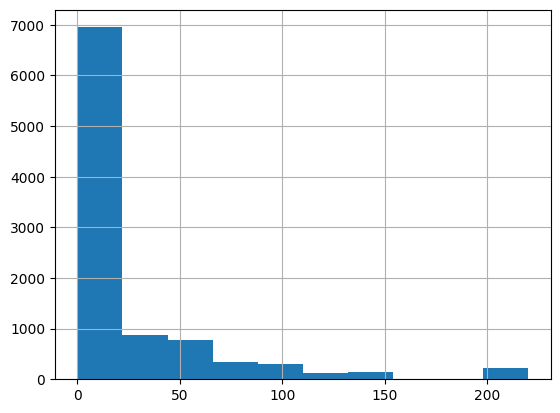

In [403]:
df['calculated_host_listings_count_entire_homes'].hist()

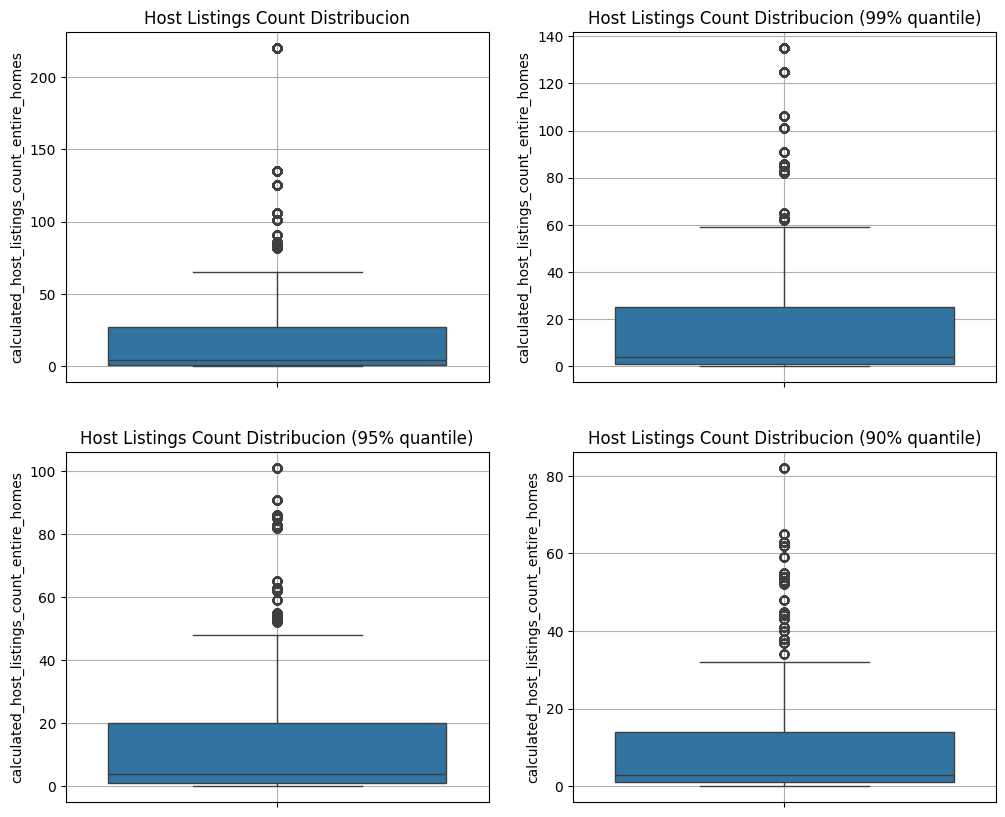

In [404]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.boxplot(df['calculated_host_listings_count_entire_homes'])
plt.title('Host Listings Count Distribucion')
plt.grid(True)

plt.subplot(2,2,2)
sns.boxplot(df[df['calculated_host_listings_count_entire_homes'] < df['calculated_host_listings_count_entire_homes'].quantile(0.99)]['calculated_host_listings_count_entire_homes'])
plt.title('Host Listings Count Distribucion (99% quantile)')
plt.grid(True)

plt.subplot(2,2,3)
sns.boxplot(df[df['calculated_host_listings_count_entire_homes'] < df['calculated_host_listings_count_entire_homes'].quantile(0.95)]['calculated_host_listings_count_entire_homes'])
plt.title('Host Listings Count Distribucion (95% quantile)')
plt.grid(True)

plt.subplot(2,2,4)
sns.boxplot(df[df['calculated_host_listings_count_entire_homes'] < df['calculated_host_listings_count_entire_homes'].quantile(0.9)]['calculated_host_listings_count_entire_homes'])
plt.title('Host Listings Count Distribucion (90% quantile)')
plt.grid(True)

plt.show()

In [405]:
np.sum(df['calculated_host_listings_count_private_rooms'].isnull())

np.int64(0)

In [406]:
private = df[df['room_type'] == 'Private room'].groupby('host_id').size()
df['calc_private'] = df['host_id'].map(private).fillna(0)

(df['calculated_host_listings_count_private_rooms'] == df['calc_private']).all()

np.True_

In [407]:
(df['calculated_host_listings_count_private_rooms'] <= df['calculated_host_listings_count']).all()

np.True_

<Axes: >

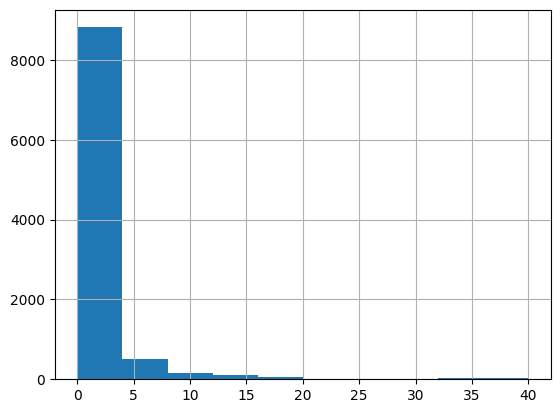

In [408]:
df['calculated_host_listings_count_private_rooms'].hist()

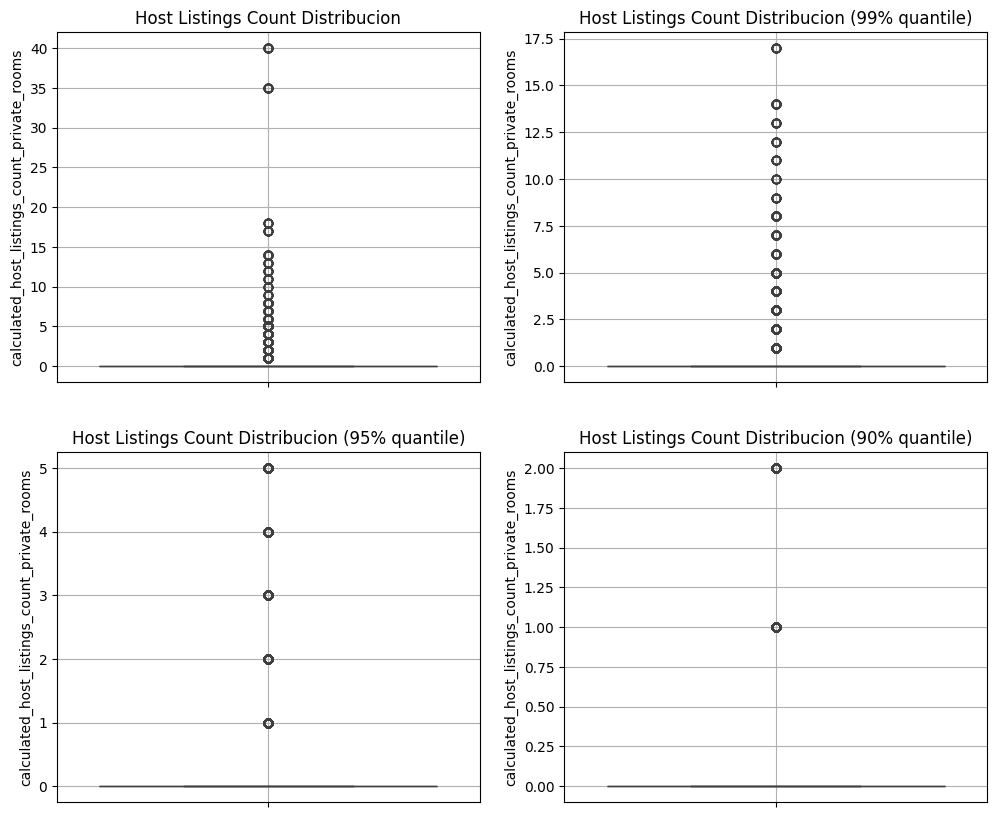

In [409]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.boxplot(df['calculated_host_listings_count_private_rooms'])
plt.title('Host Listings Count Distribucion')
plt.grid(True)

plt.subplot(2,2,2)
sns.boxplot(df[df['calculated_host_listings_count_private_rooms'] < df['calculated_host_listings_count_private_rooms'].quantile(0.99)]['calculated_host_listings_count_private_rooms'])
plt.title('Host Listings Count Distribucion (99% quantile)')
plt.grid(True)

plt.subplot(2,2,3)
sns.boxplot(df[df['calculated_host_listings_count_private_rooms'] < df['calculated_host_listings_count_private_rooms'].quantile(0.95)]['calculated_host_listings_count_private_rooms'])
plt.title('Host Listings Count Distribucion (95% quantile)')
plt.grid(True)

plt.subplot(2,2,4)
sns.boxplot(df[df['calculated_host_listings_count_private_rooms'] < df['calculated_host_listings_count_private_rooms'].quantile(0.9)]['calculated_host_listings_count_private_rooms'])
plt.title('Host Listings Count Distribucion (90% quantile)')
plt.grid(True)

plt.show()

In [410]:
np.sum(df['calculated_host_listings_count_shared_rooms'].isnull())

np.int64(0)

In [411]:
shared = df[df['room_type'] == 'Shared room'].groupby('host_id').size()
df['calc_shared'] = df['host_id'].map(shared).fillna(0)

(df['calculated_host_listings_count_shared_rooms'] == df['calc_shared']).all()

np.True_

In [412]:
(df['calculated_host_listings_count_shared_rooms'] <= df['calculated_host_listings_count']).all()

np.True_

<Axes: >

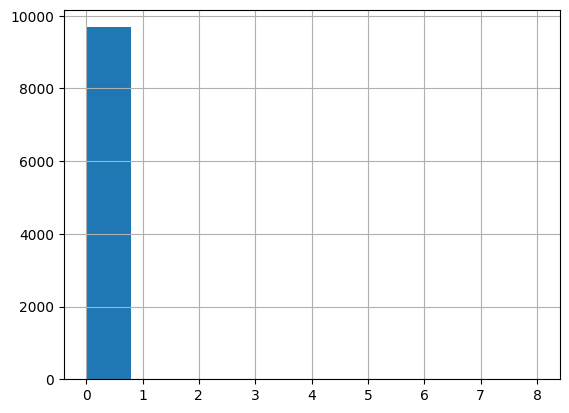

In [413]:
df['calculated_host_listings_count_shared_rooms'].hist()

In [414]:
(df['calculated_host_listings_count_shared_rooms'] == 0).all()

np.False_

In [415]:
df['calculated_host_listings_count_shared_rooms'].unique()

array([0, 1, 6, 5, 8])

In [416]:
df.groupby('host_id')['calculated_host_listings_count_shared_rooms'].first().value_counts()

calculated_host_listings_count_shared_rooms
0    3499
1       2
5       1
6       1
8       1
Name: count, dtype: int64

In [417]:
df['sum_known_rooms'] = (
    df['calculated_host_listings_count_entire_homes'] +
    df['calculated_host_listings_count_private_rooms'] +
    df['calculated_host_listings_count_shared_rooms']
)

df['other_rooms'] = df['calculated_host_listings_count'] - df['sum_known_rooms']

hosts_other = df.groupby('host_id')['other_rooms'].first()
hosts_other_nonzero = hosts_other[hosts_other > 0]
hosts_other_nonzero

host_id
68846563     1
273734646    3
Name: other_rooms, dtype: int64

In [418]:
df[df['room_type'] == 'Hotel room'].groupby('host_id').size()

host_id
68846563     1
273734646    3
dtype: int64

In [419]:
np.sum(df['host_location'].isnull())

np.int64(2280)

In [420]:
df['host_location'].nunique()

206

In [421]:
df['host_location'].unique()

<StringArray>
[           'Andalusia, Spain',              'El Faro, Spain',
                       'Spain',               'Malaga, Spain',
               'Málaga, Spain',                           nan,
 'Alhaurín de la Torre, Spain',          'Frankfurt, Germany',
            'Zoersel, Belgium',                       'Italy',
 ...
             'Zaragoza, Spain',             'La Zubia, Spain',
            'La Rambla, Spain',              'Pompeii, Italy',
             'Florence, Italy',                   'Singapore',
 'Canillas de Aceituno, Spain',           'Vancouver, Canada',
              'Moscow, Russia',              'Warsaw, Poland']
Length: 207, dtype: str

In [422]:
np.sum(df['host_neighbourhood'].isnull())

np.int64(8468)

In [423]:
df['host_location'] = df['host_location'].fillna('Unknown').astype(str).str.lower()

condiciones = [
    df['host_location'] == 'unknown',
    df['host_location'].str.contains('málaga|malaga'),
    df['host_location'].str.contains('españa|spain|madrid|barcelona|andalucía|andalucia|andalusia')
]
etiquetas = ['Unkown', 'Malaga', 'Spain']

df['host_location'] = np.select(condiciones, etiquetas, default='International')

print(df['host_location'].value_counts())

host_location
Malaga           4946
Unkown           2280
Spain            2213
International     275
Name: count, dtype: int64


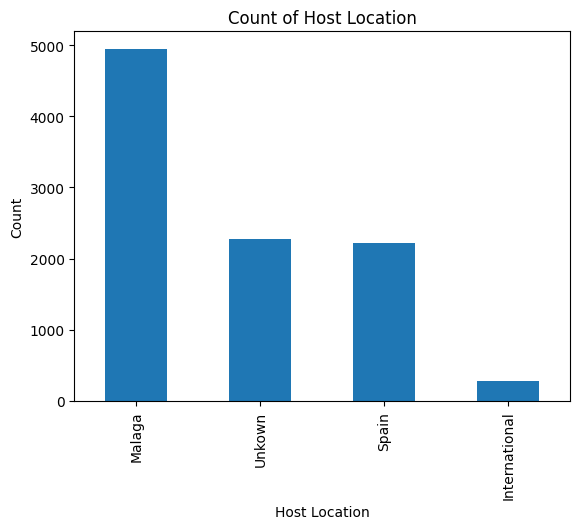

In [424]:
counts = df['host_location'].value_counts()

counts.plot(kind='bar')
plt.xlabel('Host Location')
plt.ylabel('Count')
plt.title('Count of Host Location')
plt.show()

In [425]:
np.sum(df['host_has_profile_pic'].isnull())

np.int64(0)

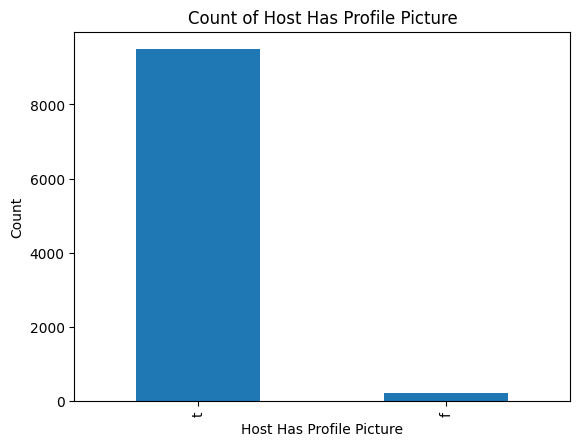

In [426]:
counts = df['host_has_profile_pic'].value_counts()

counts.plot(kind='bar')
plt.xlabel('Host Has Profile Picture')
plt.ylabel('Count')
plt.title('Count of Host Has Profile Picture')
plt.show()

In [427]:
df['host_has_profile_pic'] = df['host_has_profile_pic'] == 't'

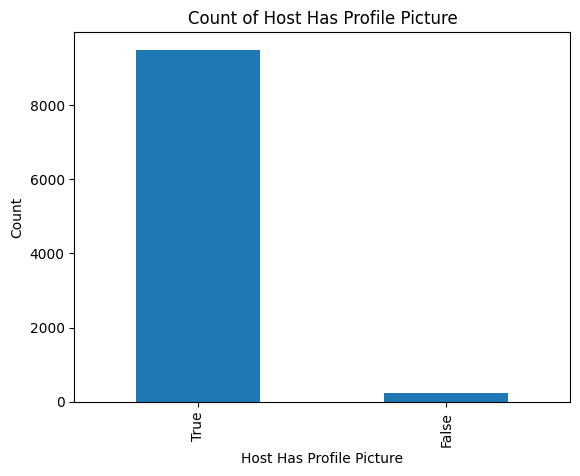

In [428]:
counts = df['host_has_profile_pic'].value_counts()

counts.plot(kind='bar')
plt.xlabel('Host Has Profile Picture')
plt.ylabel('Count')
plt.title('Count of Host Has Profile Picture')
plt.show()

**Conclusiones más importantes**

- Pasar *host_since* a formate de fecha.
- 265 valores nulos en la variable *host_is_superhost*. Para imputar estos valores, hemos buscado la información de superhost en Airbnb, y se necesita las siguientes condiciones:
    - Haber anfitrionado al menos 10 reservaciones, o 3 reservaciones que sumen al menos 100 noches. Para verificar este requisito, miraremos si tiene un valor mayor de 10 en la variable *number_of_reviews* respecto a ese anuncio.
    - Mantener un índice de respuesta mínimo del 90 % (*host_response_rate*).
    - Mantener un índice de cancelación inferior al 1 % (*host_acceptance_rate*).
    - Mantener una valoración general de 4,8 o más (*review_scores_rating*).
    - Tras ver estos requisitos, tenemos realmente un solo valor nulo en esta variable. No podemos saberlo porque sus variables de *host_response_rate* y *host_acceptance_rate* son nulos también. Como tiene 121 reviews su único anuncio y un rating medio de 4.85, lo pondremos como superhost.
- Pasar a formato *bool* las variables *host_is_superhost* y *host_identify_verified*.
- Pasar a número el texto de la variable
- 929 valores nulos en la variable *host_response_time*. Las posibles soluciones serían:
    - agregar una categoría que sea NA, ya que la variable es categórica.
    - imputar la moda según el rate del host o agrupando por la variable superhost.
- También consideramos la opción de binarizar esta variable, ya que la mayoría son de la categoría *within an hour*. Podríamos hacerla binaria, siendo 1 si tarda menos de una hora y 0 en caso contrario.
- Variables *host_response_time* y *host_acceptance_rate* están en formato *string.* Pasamos estas variables a *float*.
- 629 valores nulos en la variable *acceptance_rate*. Imputamos estos valores agrupando por la variable *host_is_superhost* y poniendo la mediana con una desviación para añadir variabilidad.
- 929 valores nulos en la variable *host_response_rate*. Imputamos estos valores agrupando por *host_is_superhost* y *host_response_time*. Ponemos la mediana con una desviación.
- La variable *host_listings_count* tiene una distribución con una cola muy pesada a la derecha, parecida a la de *price*. Por ello, también se considera hacer una transformación logarítmica o *zipf*.
- Transformación similar a la anterior mencionada para *host_total_listings_count*.
- Aplicamos OHE a la variable *host_verifications*. Solamente hay 6 verificaciones diferentes en todo el dataset: ***email, phone, work_email,*** y ***photographer**.* También hay un anuncio sin ninguna verificación, por lo que tendrá el valor de 0 en todas las variables binarias anteriores.
- Crear nueva variable de *calculated_host_listings_count_hotel_rooms*, que es la diferencia de los anuncios totales menos los tipos de habitación ya conocidos.
- Eliminar variables redundantes de conteo de anuncios por host. Nos quedamos con las variables *host_listings_count, calculated_host_listings_count_** para tener los anuncios de cada host en nuestro dataset y separado por tipo de habitación. También mantenemos la de *host_total_listings_count* ya que son el número de anuncios total de los hosts, teniendo en cuenta los que no están en el dataset. Las llamaremos:
    - *host_listings*: número de anuncios del host en el dataset.
    - *host_listings_{room_type}:* número de anuncios del host del tipo *room_type* en el dataset.
    - *host_listings_real*: número real de anuncios del host, teniendo en cuenta los de fuera del dataset.

## Variables de ubicación

In [429]:
np.sum(df['neighbourhood_cleansed'].isnull())

np.int64(0)

In [430]:
df['neighbourhood_cleansed'].unique()

<StringArray>
[                'Este',               'Centro',            'Churriana',
   'Carretera de Cadiz',  'Cruz De Humilladero', 'Teatinos-Universidad',
   'Puerto de la Torre',        'Ciudad Jardin',    'Bailen-Miraflores',
       'Palma-Palmilla',          'Campanillas']
Length: 11, dtype: str

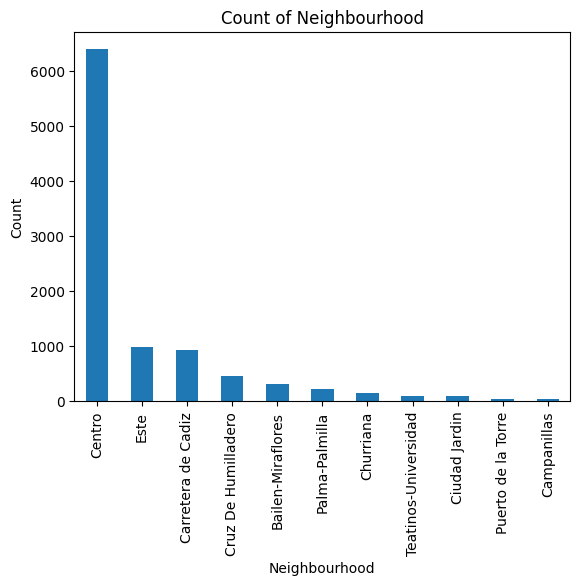

In [431]:
counts = df['neighbourhood_cleansed'].value_counts()

counts.plot(kind='bar')
plt.xlabel('Neighbourhood')
plt.ylabel('Count')
plt.title('Count of Neighbourhood')
plt.show()

In [432]:
df[~df['neighbourhood_group_cleansed'].isnull()]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,host_verifications_ast,email,phone,photographer,work_email,calc_entire,calc_private,calc_shared,sum_known_rooms,other_rooms


In [433]:
df['neighbourhood_center'] = (df['neighbourhood_cleansed'] == 'Centro').astype(int)

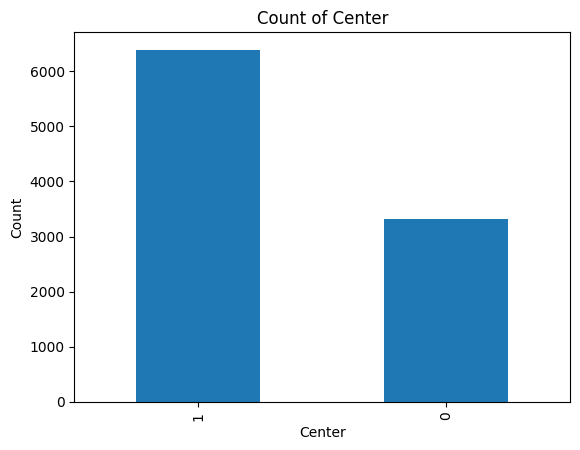

In [434]:
counts = df['neighbourhood_center'].value_counts()

counts.plot(kind='bar')
plt.xlabel('Center')
plt.ylabel('Count')
plt.title('Count of Center')
plt.show()

In [435]:
np.sum(df['neighborhood_overview'].isnull())

np.int64(5544)

In [436]:
df[~df['neighborhood_overview'].isnull()]['neighborhood_overview']

0       200 metres from the beaches of El Palo, Malaga...
2       Málaga Lodge is situated next to the famous Sa...
3       It is a central area and has all kinds of serv...
4       The apartment is in the very heart of Malaga C...
5       In the very downtown centre, just approx. 50m ...
                              ...                        
9669    The apartment is located in the historic centr...
9671    Welcome to the vibrant Mármoles neighborhood i...
9675    Discover Huelin, an authentic and lively neigh...
9681    Located just north of Málaga’s historic center...
9706    The apartment is located a few minutes away fr...
Name: neighborhood_overview, Length: 4170, dtype: str

In [437]:
np.sum(df['latitude'].isnull())

np.int64(0)

In [438]:
np.sum(df['longitude'].isnull())

np.int64(0)

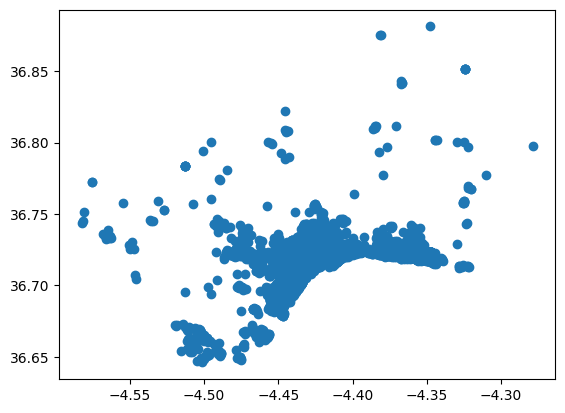

In [439]:
plt.scatter(df['longitude'], df['latitude'])
plt.show()

In [440]:
df[
    ~((df['latitude'].between(36.30, 37.10)) &
      (df['longitude'].between(-5.60, -3.90)))
]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,email,phone,photographer,work_email,calc_entire,calc_private,calc_shared,sum_known_rooms,other_rooms,neighbourhood_center


## Variables de disponibilidad

In [441]:
np.sum(df['has_availability'].isnull())

np.int64(88)

In [442]:
df['has_availability'].unique()

<StringArray>
['t', nan]
Length: 2, dtype: str

In [443]:
df.groupby(df['has_availability'].isna())['availability_365'].describe()

,count,mean,std,min,25%,50%,75%,max
has_availability,,,,,,,,
False,9626.0,209.463017,121.265942,0.0,92.0,237.0,324.00,365.0
True,88.0,96.261364,148.039176,0.0,0.0,0.0,203.25,365.0


In [444]:
np.sum(
    (df['availability_365'] == 0) &
    (df['has_availability'] == 't')
)

np.int64(528)

In [445]:
np.sum(
    (df['availability_365'] > 0) &
    (df['has_availability'].isnull())
)

np.int64(28)

In [446]:
df.loc[
    (df['availability_365'] > 0) &
    (df['has_availability'].isnull()),
    'has_availability'
] = 't'

In [447]:
np.sum(df['has_availability'].isnull())

np.int64(60)

In [448]:
df.loc[df['has_availability'].isnull(), 'has_availability'] = 'f'

In [449]:
df['has_availability'] = (df['has_availability'] == 't').astype(int)

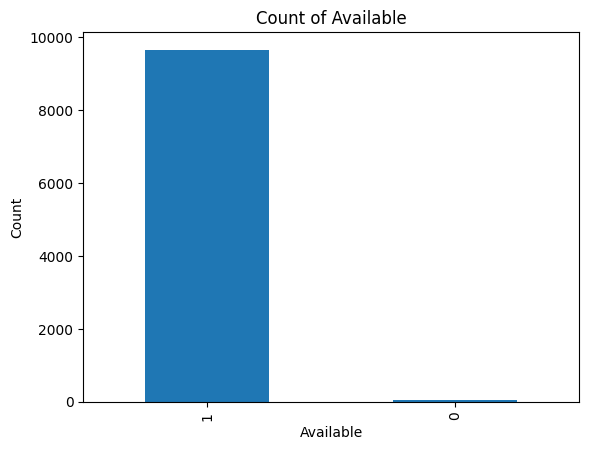

In [450]:
counts = df['has_availability'].value_counts()

counts.plot(kind='bar')
plt.xlabel('Available')
plt.ylabel('Count')
plt.title('Count of Available')
plt.show()

In [451]:
np.sum(df['availability_30'].isnull())

np.int64(0)

<Axes: >

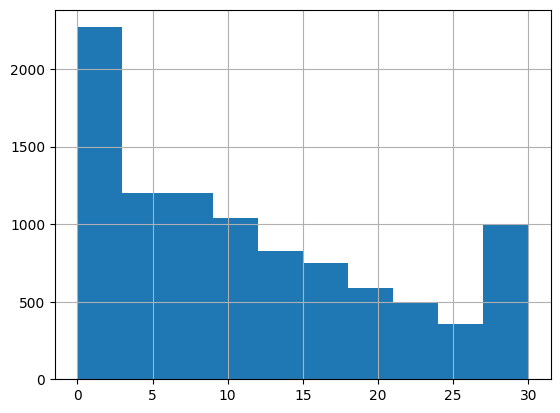

In [452]:
df['availability_30'].hist()

In [453]:
np.sum(df['availability_60'].isnull())

np.int64(0)

<Axes: >

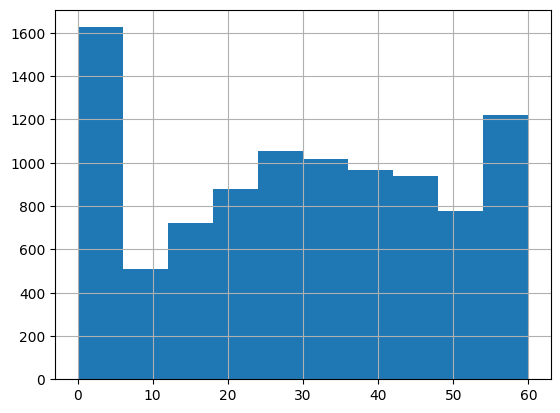

In [454]:
df['availability_60'].hist()

In [455]:
np.sum(df['availability_90'].isnull())

np.int64(0)

<Axes: >

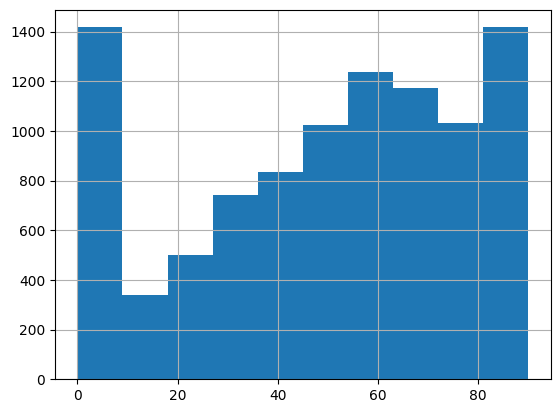

In [456]:
df['availability_90'].hist()

In [457]:
np.sum(df['availability_365'].isnull())

np.int64(0)

<Axes: >

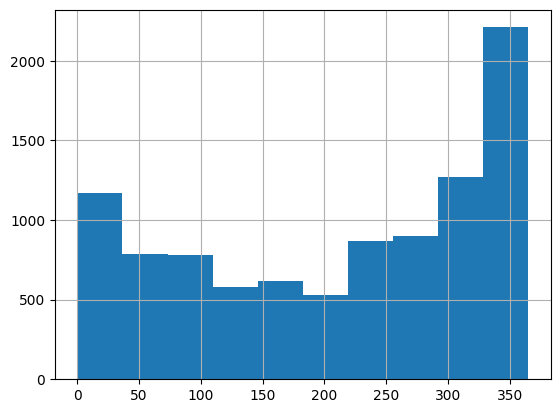

In [458]:
df['availability_365'].hist()

In [459]:
np.sum(df['availability_eoy'].isnull())

np.int64(0)

<Axes: >

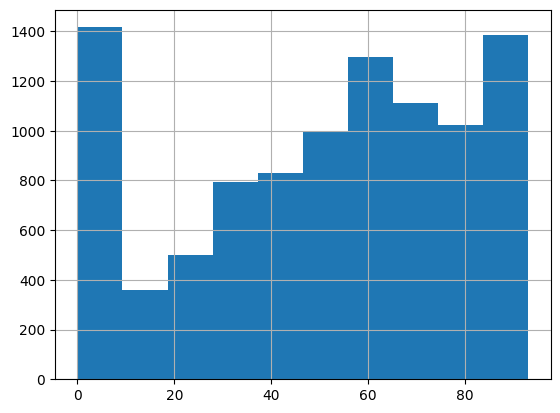

In [460]:
df['availability_eoy'].hist()

In [461]:
np.sum(df['estimated_occupancy_l365d'].isnull())

np.int64(0)

<Axes: >

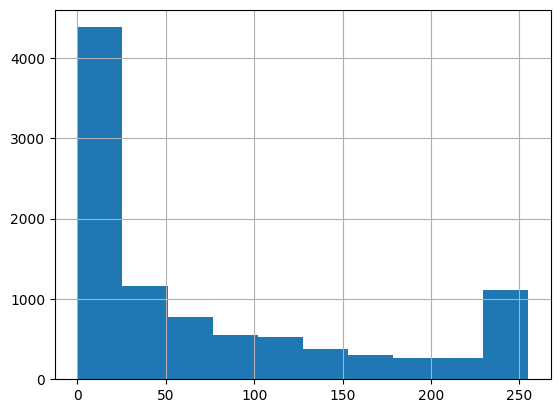

In [462]:
df['estimated_occupancy_l365d'].hist()

In [463]:
np.sum(df['estimated_revenue_l365d'].isnull())

np.int64(899)

<Axes: >

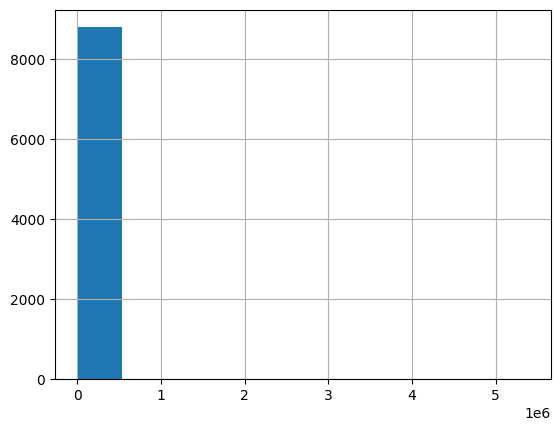

In [464]:
df['estimated_revenue_l365d'].hist()

In [465]:
(df['estimated_revenue_l365d'] - df['estimated_occupancy_l365d'] * df['price_num']).describe()

count    8815.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: float64

In [466]:
df['estimated_revenue_l365d'] = df['estimated_revenue_l365d'].fillna(
    df['estimated_occupancy_l365d'] * df['price_num']
)

<Axes: >

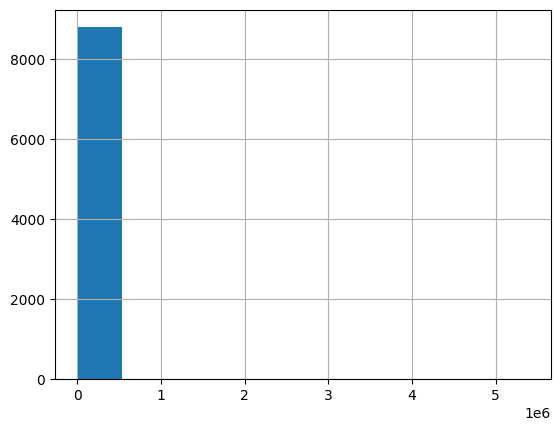

In [467]:
df['estimated_revenue_l365d'].hist()

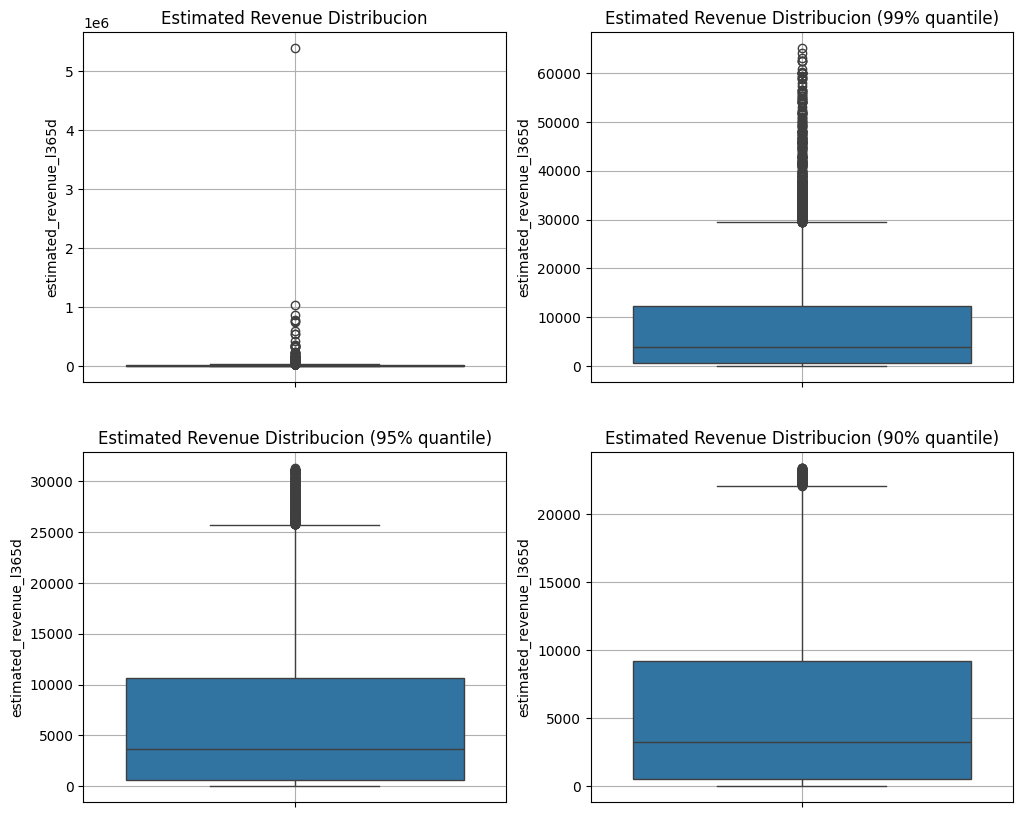

In [468]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.boxplot(df['estimated_revenue_l365d'])
plt.title('Estimated Revenue Distribucion')
plt.grid(True)

plt.subplot(2,2,2)
sns.boxplot(df[df['estimated_revenue_l365d'] < df['estimated_revenue_l365d'].quantile(0.99)]['estimated_revenue_l365d'])
plt.title('Estimated Revenue Distribucion (99% quantile)')
plt.grid(True)

plt.subplot(2,2,3)
sns.boxplot(df[df['estimated_revenue_l365d'] < df['estimated_revenue_l365d'].quantile(0.95)]['estimated_revenue_l365d'])
plt.title('Estimated Revenue Distribucion (95% quantile)')
plt.grid(True)

plt.subplot(2,2,4)
sns.boxplot(df[df['estimated_revenue_l365d'] < df['estimated_revenue_l365d'].quantile(0.9)]['estimated_revenue_l365d'])
plt.title('Estimated Revenue Distribucion (90% quantile)')
plt.grid(True)

plt.show()

In [469]:
df[
    df['estimated_revenue_l365d'] > 5*1e6
][['estimated_occupancy_l365d', 'price_num', 'listing_url', 'id']]

,estimated_occupancy_l365d,price_num,listing_url,id
2629,246,21911.0,https://www.airbnb.com/rooms/47444051,47444051


In [470]:
df.loc[df['id'] == 47444051, 'price_num'] = 182

In [471]:
mask = df['id'] == 47444051
df.loc[mask, 'estimated_revenue_l365d'] = (
    df.loc[mask, 'estimated_occupancy_l365d'] * df.loc[mask, 'price_num']
)

<Axes: >

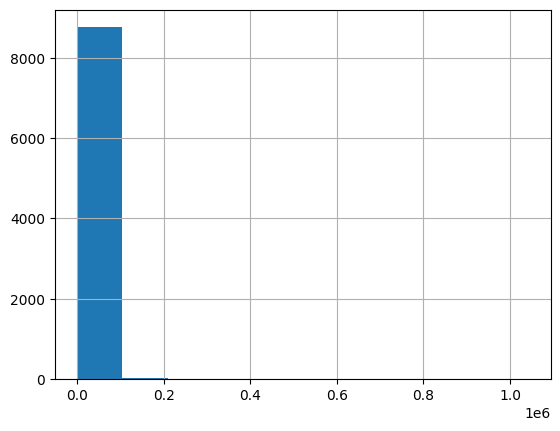

In [472]:
df['estimated_revenue_l365d'].hist()

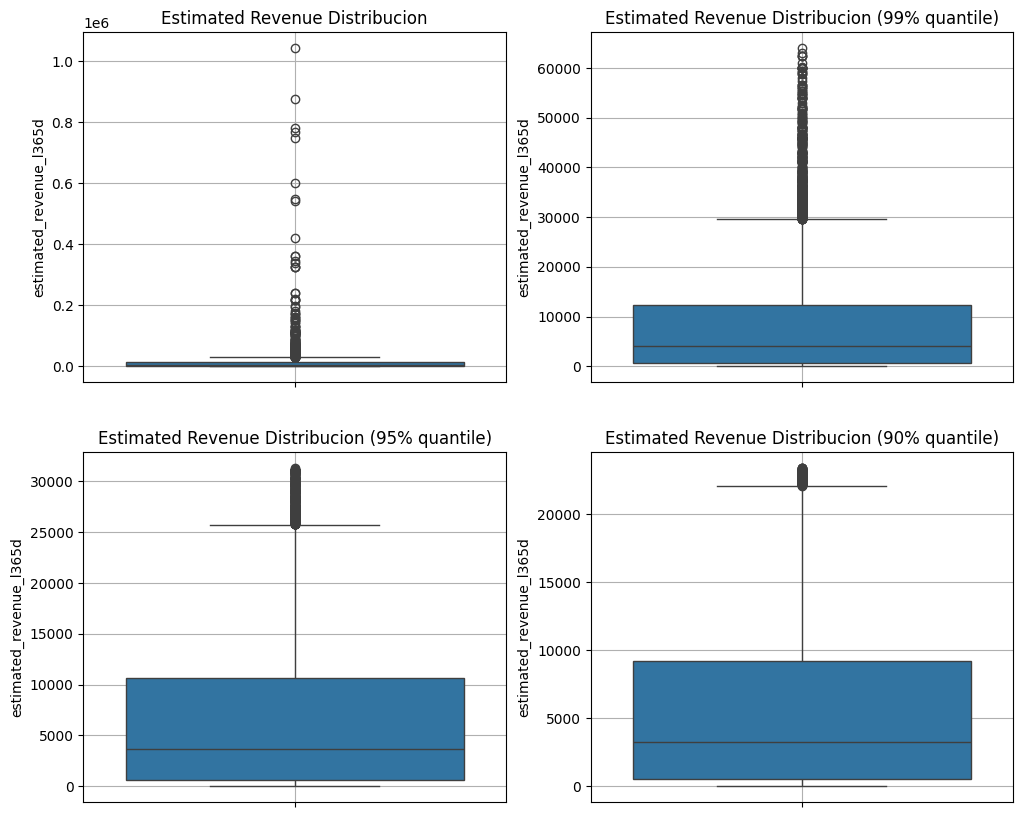

In [473]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.boxplot(df['estimated_revenue_l365d'])
plt.title('Estimated Revenue Distribucion')
plt.grid(True)

plt.subplot(2,2,2)
sns.boxplot(df[df['estimated_revenue_l365d'] < df['estimated_revenue_l365d'].quantile(0.99)]['estimated_revenue_l365d'])
plt.title('Estimated Revenue Distribucion (99% quantile)')
plt.grid(True)

plt.subplot(2,2,3)
sns.boxplot(df[df['estimated_revenue_l365d'] < df['estimated_revenue_l365d'].quantile(0.95)]['estimated_revenue_l365d'])
plt.title('Estimated Revenue Distribucion (95% quantile)')
plt.grid(True)

plt.subplot(2,2,4)
sns.boxplot(df[df['estimated_revenue_l365d'] < df['estimated_revenue_l365d'].quantile(0.9)]['estimated_revenue_l365d'])
plt.title('Estimated Revenue Distribucion (90% quantile)')
plt.grid(True)

plt.show()

## Variables de reseñas

In [474]:
np.sum(df['number_of_reviews'].isnull())

np.int64(0)

<Axes: >

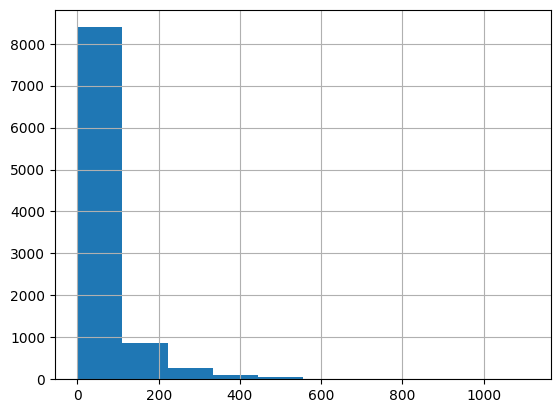

In [475]:
df['number_of_reviews'].hist()

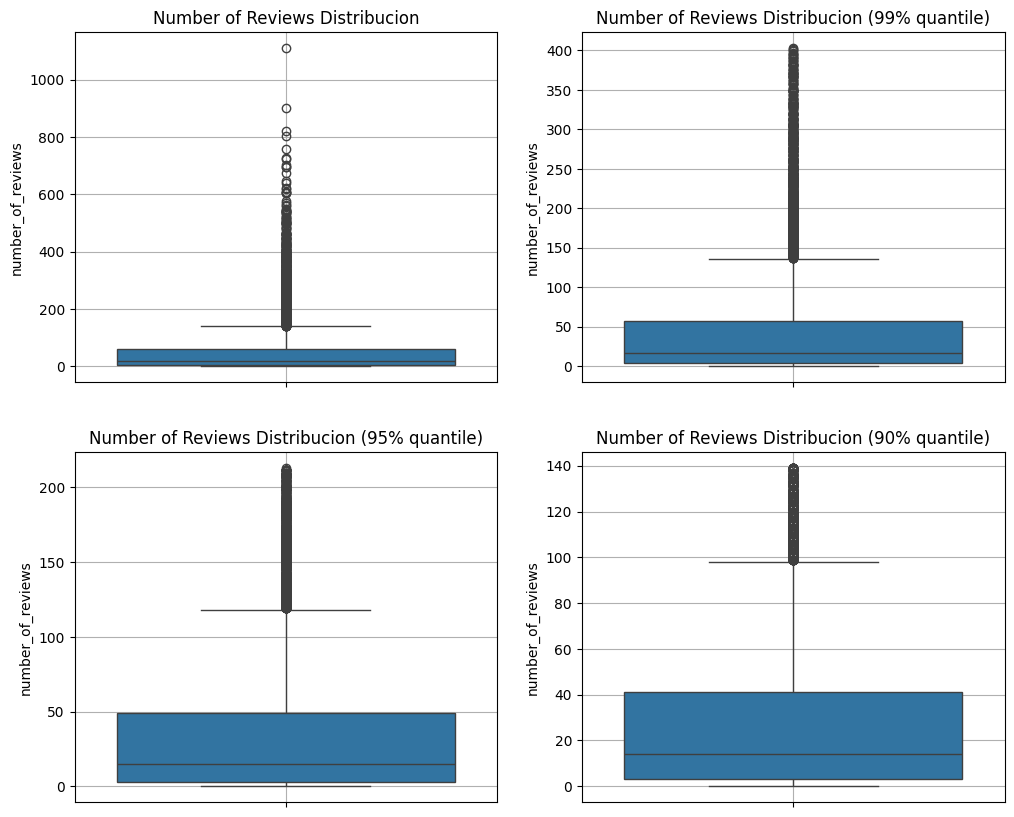

In [476]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.boxplot(df['number_of_reviews'])
plt.title('Number of Reviews Distribucion')
plt.grid(True)

plt.subplot(2,2,2)
sns.boxplot(df[df['number_of_reviews'] < df['number_of_reviews'].quantile(0.99)]['number_of_reviews'])
plt.title('Number of Reviews Distribucion (99% quantile)')
plt.grid(True)

plt.subplot(2,2,3)
sns.boxplot(df[df['number_of_reviews'] < df['number_of_reviews'].quantile(0.95)]['number_of_reviews'])
plt.title('Number of Reviews Distribucion (95% quantile)')
plt.grid(True)

plt.subplot(2,2,4)
sns.boxplot(df[df['number_of_reviews'] < df['number_of_reviews'].quantile(0.9)]['number_of_reviews'])
plt.title('Number of Reviews Distribucion (90% quantile)')
plt.grid(True)

plt.show()

In [477]:
np.sum(df['number_of_reviews'] == 0)

np.int64(1005)

In [478]:
df[
    df['number_of_reviews'] == 0
].head(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,email,phone,photographer,work_email,calc_entire,calc_private,calc_shared,sum_known_rooms,other_rooms,neighbourhood_center
27,786648,https://www.airbnb.com/rooms/786648,20250930030808,2025-09-30,city scrape,"APARTAMENT 1 bedroom, for 2 Persons",San Pablo Apartments is a complex consisting o...,"Located in the center of Malaga, a 5-minute wa...",https://a0.muscache.com/pictures/087756ca-4158...,4147118,...,1,1,0,0,9.0,0.0,0.0,9,0,1
29,786656,https://www.airbnb.com/rooms/786656,20250930030808,2025-09-30,city scrape,"Attic Studio, for 2 people.","Penthouse, located on the terrace of the build...","In the Barrio, you can find it from the best f...",https://a0.muscache.com/pictures/11044640/b258...,4147118,...,1,1,0,0,9.0,0.0,0.0,9,0,1
132,3992497,https://www.airbnb.com/rooms/3992497,20250930030808,2025-09-30,city scrape,Minimal Rooms Ⅰ by ELE Apartments,"Located in the heart of Malaga, just 50 meters...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,89812313,...,1,1,0,0,106.0,0.0,0.0,106,0,1
173,4972419,https://www.airbnb.com/rooms/4972419,20250930030808,2025-09-30,city scrape,"Jasmine with amazing views, pool and tennis",Padre Aviles is a 17th Century converted conve...,We are 7 kms (10 mins drive) up a windy hill f...,https://a0.muscache.com/pictures/70543238/22d0...,25632968,...,1,1,0,0,8.0,0.0,0.0,8,0,0
349,10712072,https://www.airbnb.com/rooms/10712072,20250930030808,2025-09-30,city scrape,Moderne studio nabij historisch centrum Málaga,NaN,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,55359972,...,1,1,0,0,1.0,0.0,0.0,1,0,1


In [479]:
df['has_review'] = df['number_of_reviews'] > 0

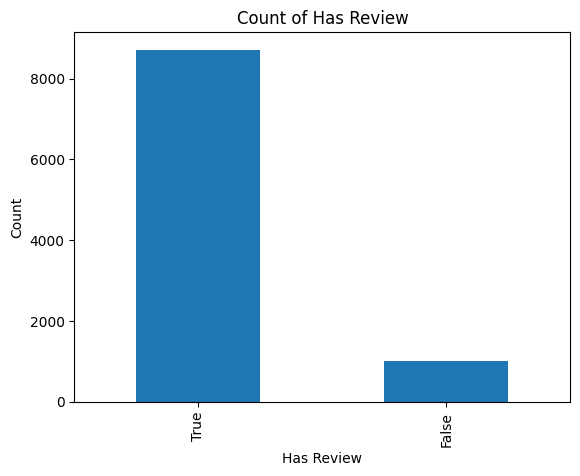

In [480]:
counts = df['has_review'].value_counts()

counts.plot(kind='bar')
plt.xlabel('Has Review')
plt.ylabel('Count')
plt.title('Count of Has Review')
plt.show()

In [481]:
np.sum(df['first_review'].isnull())

np.int64(1005)

In [482]:
df['first_review'] = pd.to_datetime(df['first_review'])

In [483]:
df['first_review'].head(5)

0   2013-10-18
1   2011-08-25
2   2012-02-23
3   2013-03-18
4   2012-04-25
Name: first_review, dtype: datetime64[us]

<Axes: >

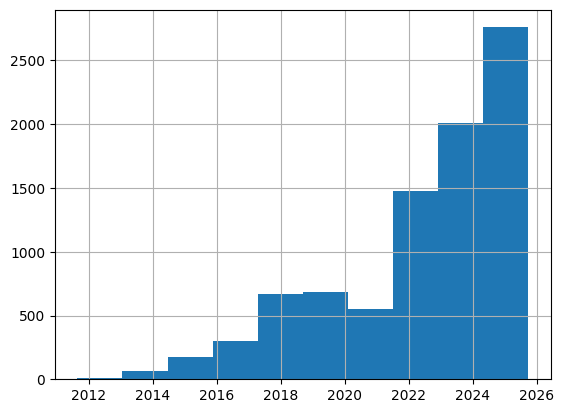

In [484]:
df['first_review'].hist()

In [485]:
np.sum(df['last_review'].isnull())

np.int64(1005)

In [486]:
df['last_review'] = pd.to_datetime(df['last_review'])

<Axes: >

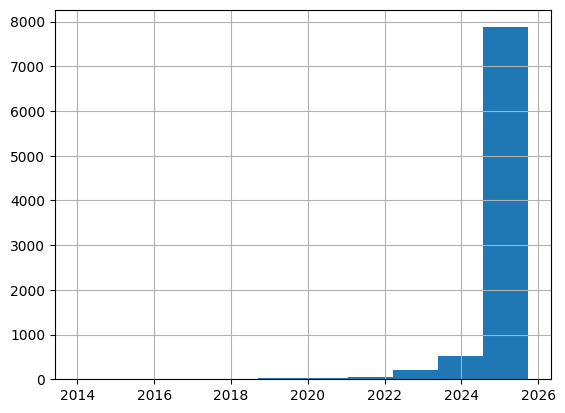

In [487]:
df['last_review'].hist()

In [488]:
df['has_review_lt'] = df['last_review'].dt.year == 2025

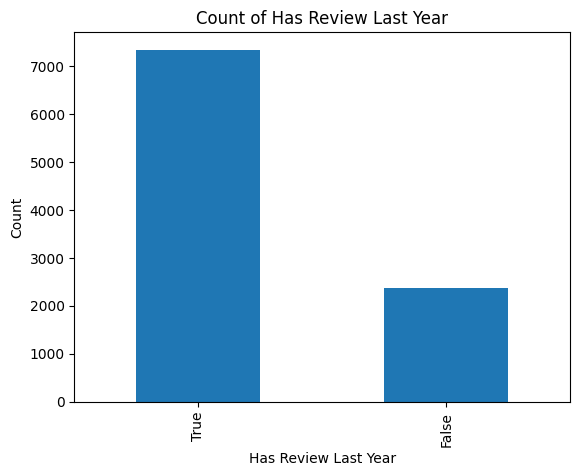

In [489]:
counts = df['has_review_lt'].value_counts()

counts.plot(kind='bar')
plt.xlabel('Has Review Last Year')
plt.ylabel('Count')
plt.title('Count of Has Review Last Year')
plt.show()

In [490]:
np.sum(df['number_of_reviews_l30d'].isnull())

np.int64(0)

<Axes: >

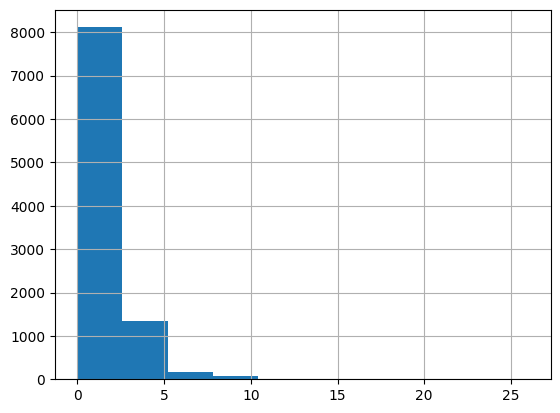

In [491]:
df['number_of_reviews_l30d'].hist()

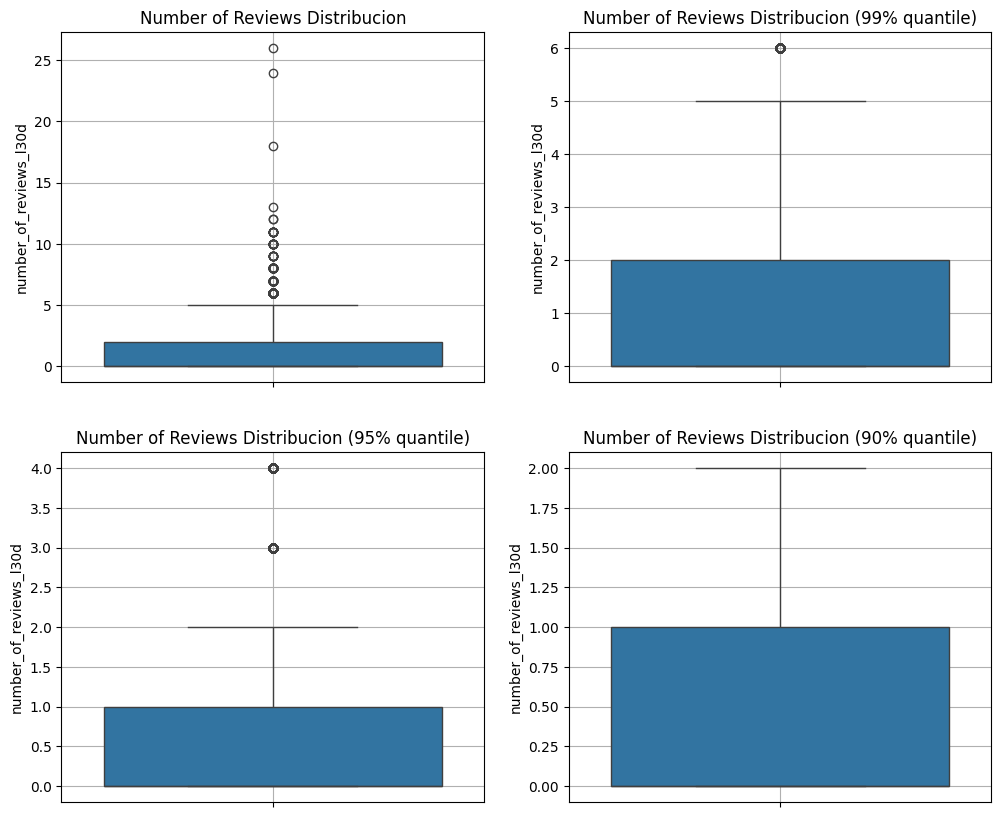

In [492]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.boxplot(df['number_of_reviews_l30d'])
plt.title('Number of Reviews Distribucion')
plt.grid(True)

plt.subplot(2,2,2)
sns.boxplot(df[df['number_of_reviews_l30d'] < df['number_of_reviews_l30d'].quantile(0.99)]['number_of_reviews_l30d'])
plt.title('Number of Reviews Distribucion (99% quantile)')
plt.grid(True)

plt.subplot(2,2,3)
sns.boxplot(df[df['number_of_reviews_l30d'] < df['number_of_reviews_l30d'].quantile(0.95)]['number_of_reviews_l30d'])
plt.title('Number of Reviews Distribucion (95% quantile)')
plt.grid(True)

plt.subplot(2,2,4)
sns.boxplot(df[df['number_of_reviews_l30d'] < df['number_of_reviews_l30d'].quantile(0.9)]['number_of_reviews_l30d'])
plt.title('Number of Reviews Distribucion (90% quantile)')
plt.grid(True)

plt.show()

In [493]:
np.sum(df['number_of_reviews_ltm'].isnull())

np.int64(0)

<Axes: >

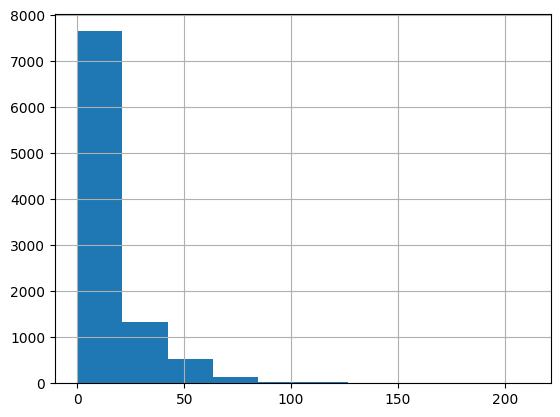

In [494]:
df['number_of_reviews_ltm'].hist()

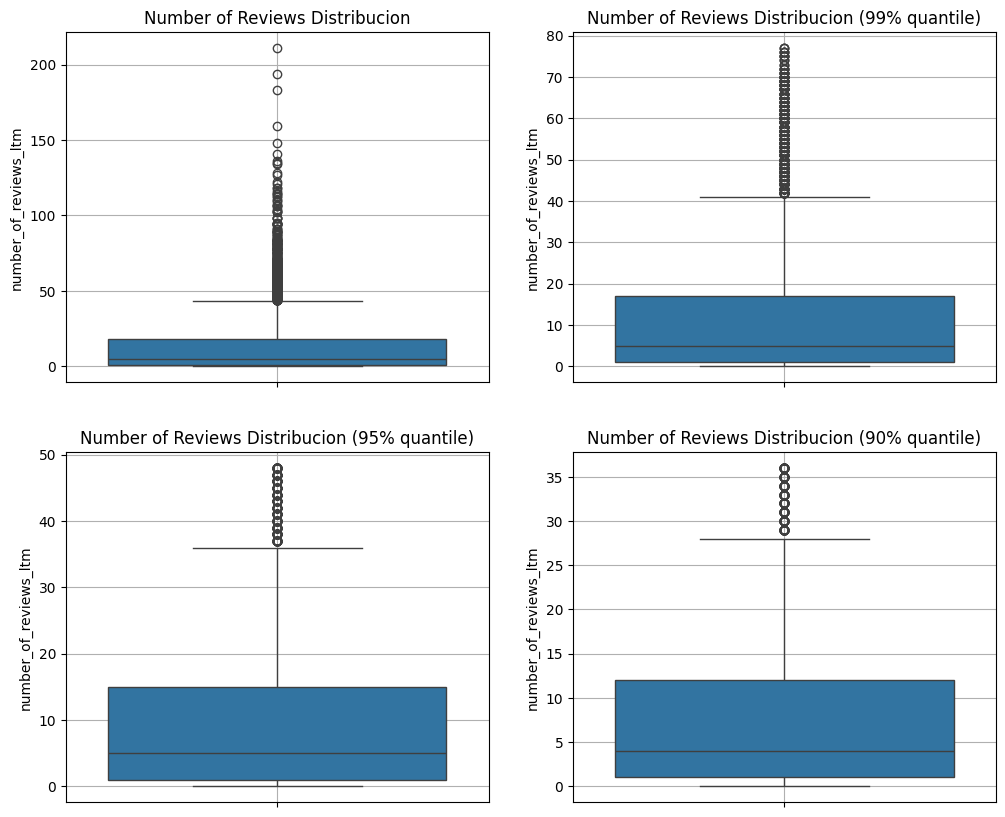

In [495]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.boxplot(df['number_of_reviews_ltm'])
plt.title('Number of Reviews Distribucion')
plt.grid(True)

plt.subplot(2,2,2)
sns.boxplot(df[df['number_of_reviews_ltm'] < df['number_of_reviews_ltm'].quantile(0.99)]['number_of_reviews_ltm'])
plt.title('Number of Reviews Distribucion (99% quantile)')
plt.grid(True)

plt.subplot(2,2,3)
sns.boxplot(df[df['number_of_reviews_ltm'] < df['number_of_reviews_ltm'].quantile(0.95)]['number_of_reviews_ltm'])
plt.title('Number of Reviews Distribucion (95% quantile)')
plt.grid(True)

plt.subplot(2,2,4)
sns.boxplot(df[df['number_of_reviews_ltm'] < df['number_of_reviews_ltm'].quantile(0.9)]['number_of_reviews_ltm'])
plt.title('Number of Reviews Distribucion (90% quantile)')
plt.grid(True)

plt.show()

In [496]:
np.sum(df['number_of_reviews_ly'].isnull())

np.int64(0)

<Axes: >

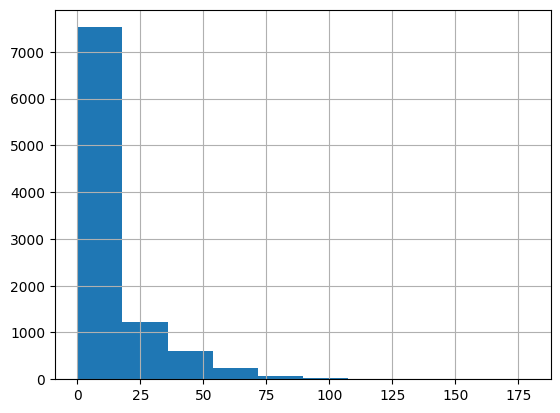

In [497]:
df['number_of_reviews_ly'].hist()

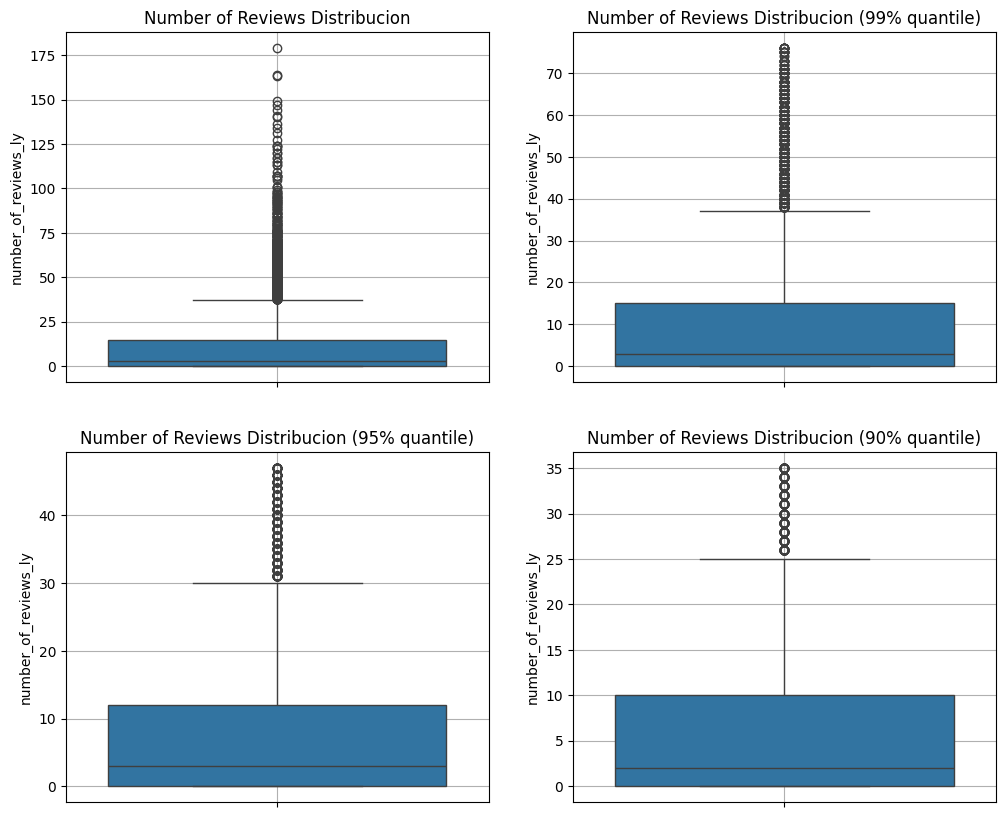

In [498]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.boxplot(df['number_of_reviews_ly'])
plt.title('Number of Reviews Distribucion')
plt.grid(True)

plt.subplot(2,2,2)
sns.boxplot(df[df['number_of_reviews_ly'] < df['number_of_reviews_ly'].quantile(0.99)]['number_of_reviews_ly'])
plt.title('Number of Reviews Distribucion (99% quantile)')
plt.grid(True)

plt.subplot(2,2,3)
sns.boxplot(df[df['number_of_reviews_ly'] < df['number_of_reviews_ly'].quantile(0.95)]['number_of_reviews_ly'])
plt.title('Number of Reviews Distribucion (95% quantile)')
plt.grid(True)

plt.subplot(2,2,4)
sns.boxplot(df[df['number_of_reviews_ly'] < df['number_of_reviews_ly'].quantile(0.9)]['number_of_reviews_ly'])
plt.title('Number of Reviews Distribucion (90% quantile)')
plt.grid(True)

plt.show()

In [499]:
np.sum(df['review_scores_rating'].isnull())

np.int64(1005)

In [500]:
np.sum(df['review_scores_accuracy'].isnull())

np.int64(1005)

In [501]:
np.sum(df['review_scores_location'].isnull())

np.int64(1005)

In [502]:
np.sum(df['review_scores_value'].isnull())

np.int64(1005)

In [503]:
np.sum(df['review_scores_cleanliness'].isnull())

np.int64(1005)

In [504]:
np.sum(df['review_scores_checkin'].isnull())

np.int64(1005)

In [505]:
np.sum(df['review_scores_communication'].isnull())

np.int64(1005)

In [506]:
np.sum(df['reviews_per_month'].isnull())

np.int64(1005)

In [507]:
np.sum(
    df['number_of_reviews'] == 0 &
    df['first_review'].isnull() &
    df['last_review'].isnull() &
    df['review_scores_rating'].isnull() &
    df['review_scores_location'].isnull() &
    df['review_scores_value'].isnull() &
    df['reviews_per_month'].isnull() &
    df['review_scores_accuracy'].isnull() &
    df['review_scores_cleanliness'].isnull() &
    df['review_scores_checkin'].isnull() &
    df['review_scores_communication'].isnull()
)

np.int64(1005)

In [508]:
df.loc[
    df['has_review'] == False,
    'reviews_per_month'
] = 0

<Axes: >

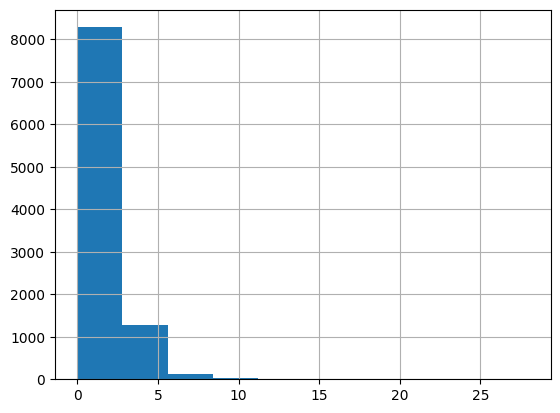

In [509]:
df['reviews_per_month'].hist()

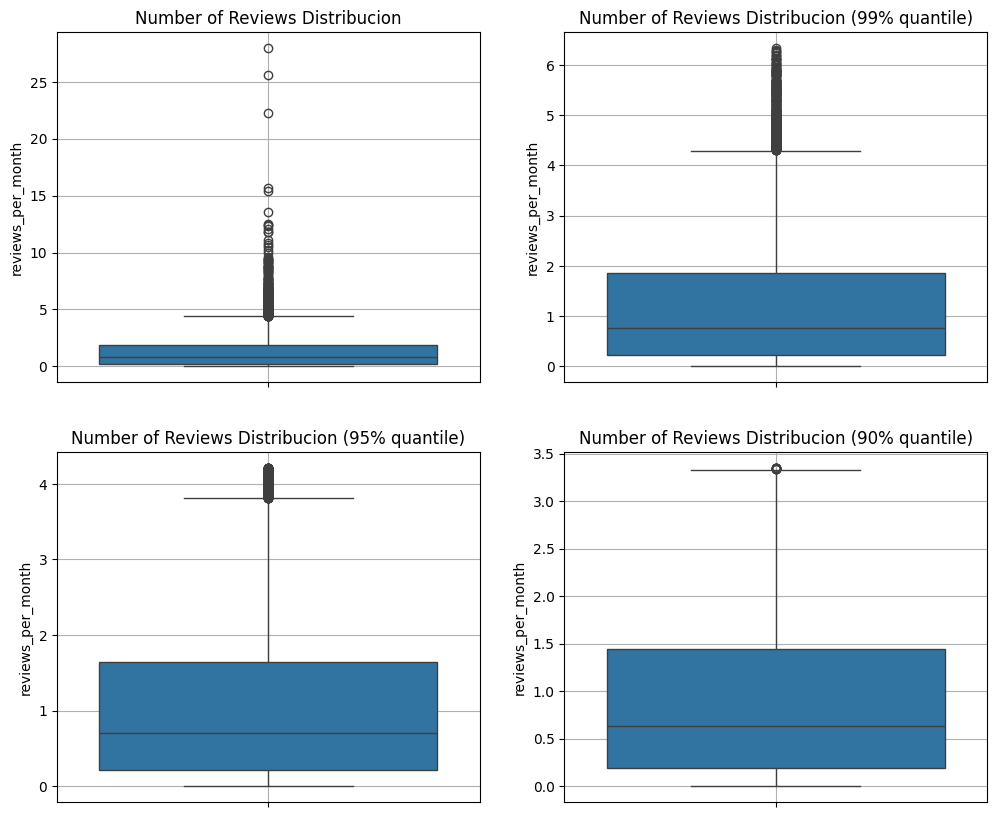

In [510]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.boxplot(df['reviews_per_month'])
plt.title('Number of Reviews Distribucion')
plt.grid(True)

plt.subplot(2,2,2)
sns.boxplot(df[df['reviews_per_month'] < df['reviews_per_month'].quantile(0.99)]['reviews_per_month'])
plt.title('Number of Reviews Distribucion (99% quantile)')
plt.grid(True)

plt.subplot(2,2,3)
sns.boxplot(df[df['reviews_per_month'] < df['reviews_per_month'].quantile(0.95)]['reviews_per_month'])
plt.title('Number of Reviews Distribucion (95% quantile)')
plt.grid(True)

plt.subplot(2,2,4)
sns.boxplot(df[df['reviews_per_month'] < df['reviews_per_month'].quantile(0.9)]['reviews_per_month'])
plt.title('Number of Reviews Distribucion (90% quantile)')
plt.grid(True)

plt.show()

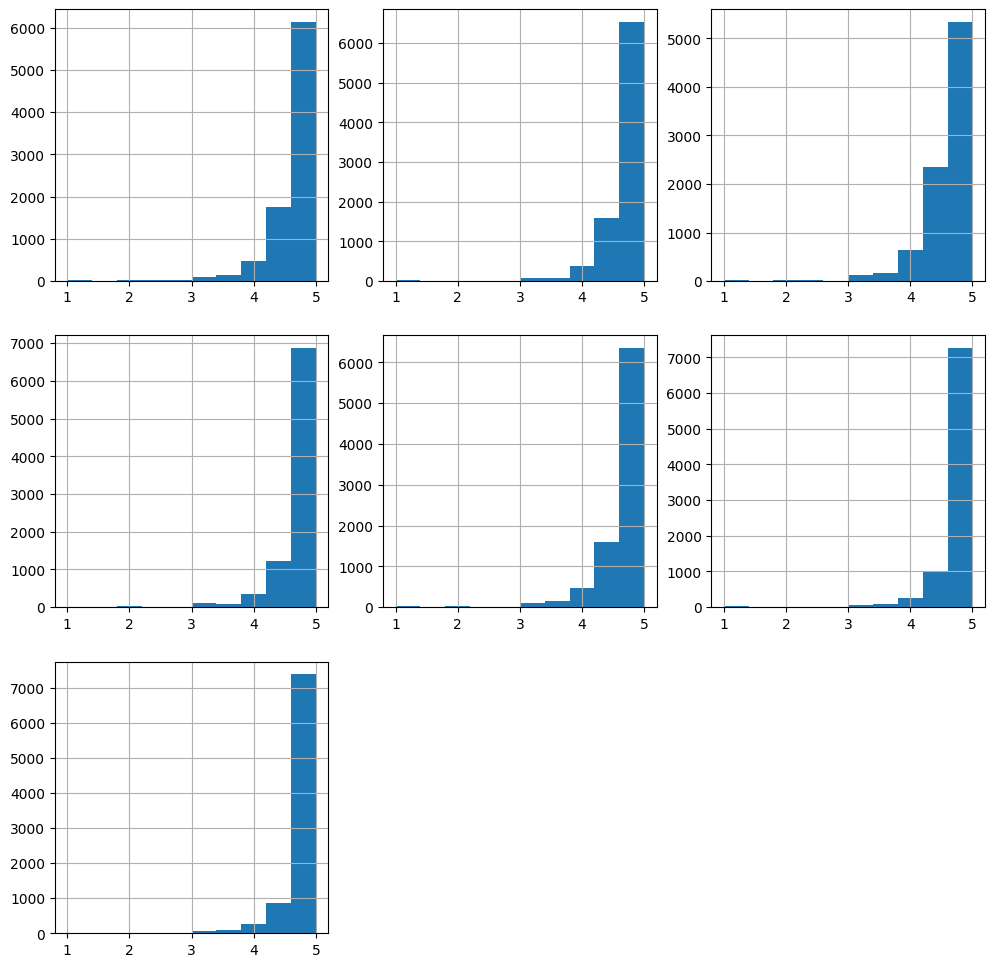

In [511]:
rating_features = ['review_scores_rating', 'review_scores_location', 'review_scores_value', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication']
plt.figure(figsize=(12,12))
for index, i in enumerate(rating_features):
    plt.subplot(3,3,index+1)
    df[i].hist()

## Variables de reglas de reserva

In [512]:
norms_features = [
    'minimum_nights',
    'maximum_nights',
    'instant_bookable',
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_maximum_nights',
    'maximum_maximum_nights',
    'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm'
]

for index, i in enumerate(norms_features):
    print(i)
    print(np.sum(df[i].isnull()))

minimum_nights
0
maximum_nights
0
instant_bookable
0
minimum_minimum_nights
3
maximum_minimum_nights
3
minimum_maximum_nights
3
maximum_maximum_nights
3
minimum_nights_avg_ntm
0
maximum_nights_avg_ntm
0


In [513]:
(df['minimum_nights'] == df['minimum_minimum_nights']).mean()

np.float64(0.6956969322627136)

In [514]:
(df['minimum_nights'] == df['maximum_minimum_nights']).mean()

np.float64(0.48044060119415277)

In [515]:
(df['maximum_nights'] == df['minimum_maximum_nights']).mean()

np.float64(0.5646489602635372)

In [516]:
(df['maximum_nights'] == df['maximum_maximum_nights']).mean()

np.float64(0.6415482808317892)

In [517]:
# Seleccionamos las columnas sospechosas de ser redundantes
columnas_noches = [
    'minimum_nights', 'minimum_minimum_nights', 'minimum_nights_avg_ntm',
    'maximum_nights', 'maximum_maximum_nights', 'maximum_nights_avg_ntm'
]

# Calculamos y mostramos la matriz de correlación
correlacion = df[columnas_noches].corr()
display(correlacion)

,minimum_nights,minimum_minimum_nights,minimum_nights_avg_ntm,maximum_nights,maximum_maximum_nights,maximum_nights_avg_ntm
minimum_nights,1.000000,0.818402,0.791237,-0.013559,-0.040441,-0.016606
minimum_minimum_nights,0.818402,1.000000,0.840392,-0.005769,-0.034672,-0.009186
minimum_nights_avg_ntm,0.791237,0.840392,1.000000,0.027185,0.011968,0.033121
maximum_nights,-0.013559,-0.005769,0.027185,1.000000,0.509891,0.413214
maximum_maximum_nights,-0.040441,-0.034672,0.011968,0.509891,1.000000,0.890005
maximum_nights_avg_ntm,-0.016606,-0.009186,0.033121,0.413214,0.890005,1.000000


<Axes: >

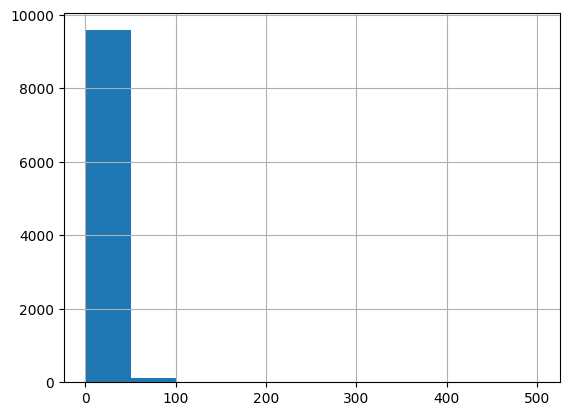

In [518]:
df['minimum_nights'].hist()

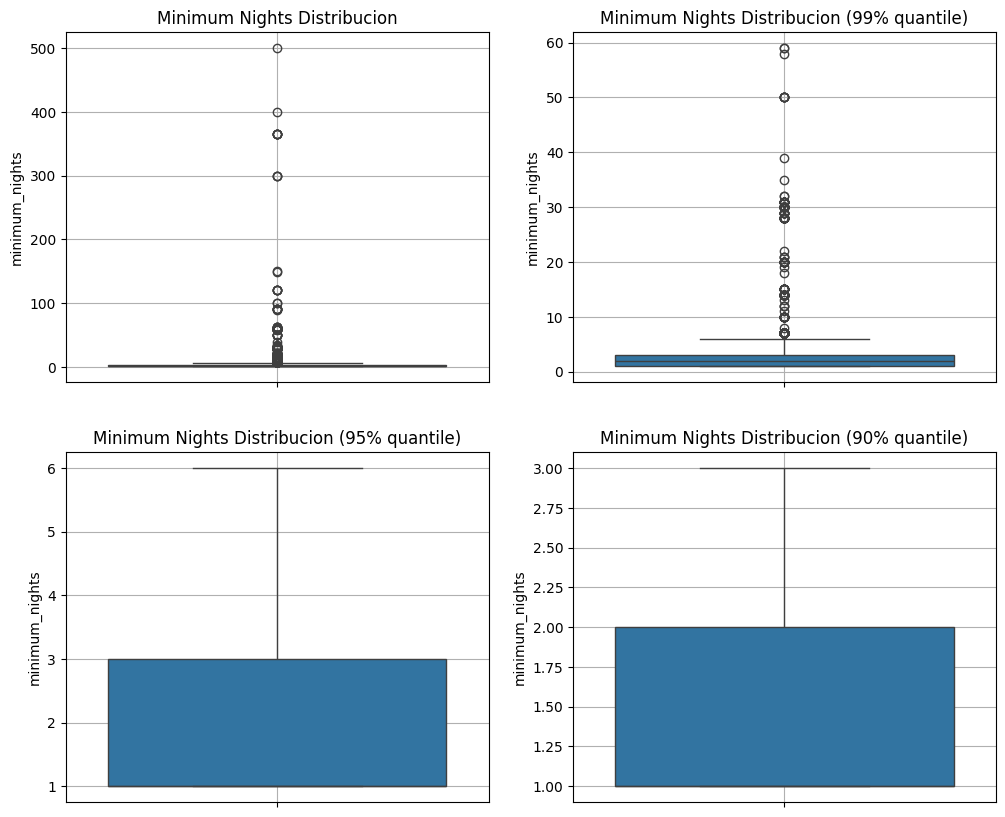

In [519]:
plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
sns.boxplot(df['minimum_nights'])
plt.title('Minimum Nights Distribucion')
plt.grid(True)

plt.subplot(2,2,2)
sns.boxplot(df[df['minimum_nights'] < df['minimum_nights'].quantile(0.99)]['minimum_nights'])
plt.title('Minimum Nights Distribucion (99% quantile)')
plt.grid(True)

plt.subplot(2,2,3)
sns.boxplot(df[df['minimum_nights'] < df['minimum_nights'].quantile(0.95)]['minimum_nights'])
plt.title('Minimum Nights Distribucion (95% quantile)')
plt.grid(True)

plt.subplot(2,2,4)
sns.boxplot(df[df['minimum_nights'] < df['minimum_nights'].quantile(0.9)]['minimum_nights'])
plt.title('Minimum Nights Distribucion (90% quantile)')
plt.grid(True)

plt.show()

In [520]:
(df['minimum_nights'] > 30).mean()

np.float64(0.015750463248919086)

In [521]:
(df['minimum_nights'] > 30).sum()

np.int64(153)

In [522]:
df[
    df['minimum_nights'] >= 500
].T

,1748
id,33862197
listing_url,https://www.airbnb.com/rooms/33862197
scrape_id,20250930030808
last_scraped,2025-09-30
source,city scrape
...,...
sum_known_rooms,1
other_rooms,0
neighbourhood_center,0
has_review,False


In [523]:
df[
    df['minimum_nights'] >= 500
][['price_num', 'listing_url']]

,price_num,listing_url
1748,100.0,https://www.airbnb.com/rooms/33862197


<Axes: >

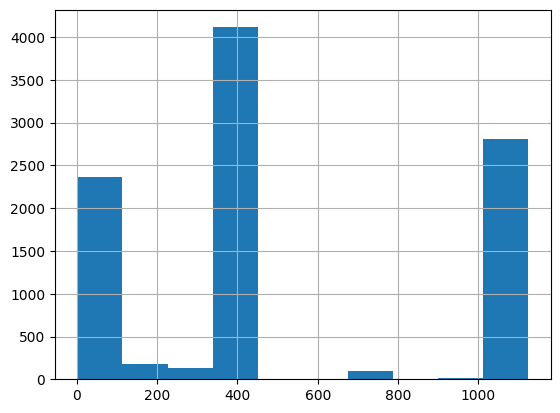

In [524]:
df['maximum_nights'].hist()

<Axes: >

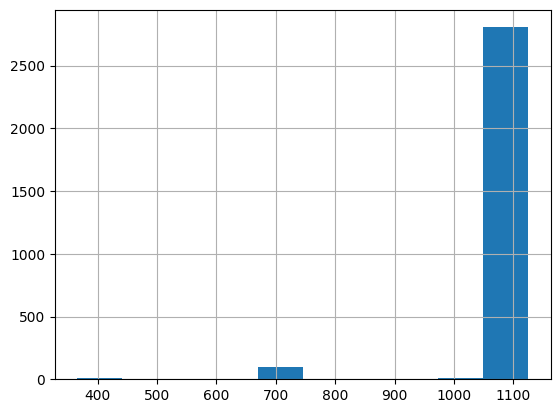

In [525]:
df[
    df['maximum_nights'] > 365
]['maximum_nights'].hist()

In [526]:
df['long_stay'] = (df['maximum_nights'] > 365)

In [527]:
df['maximum_nights'] = df['maximum_nights'].clip(upper=365)

<Axes: >

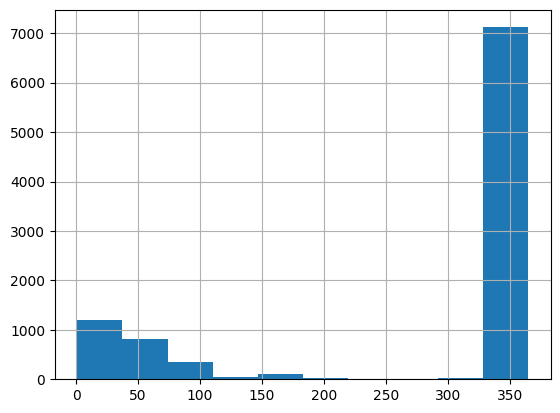

In [528]:
df['maximum_nights'].hist()

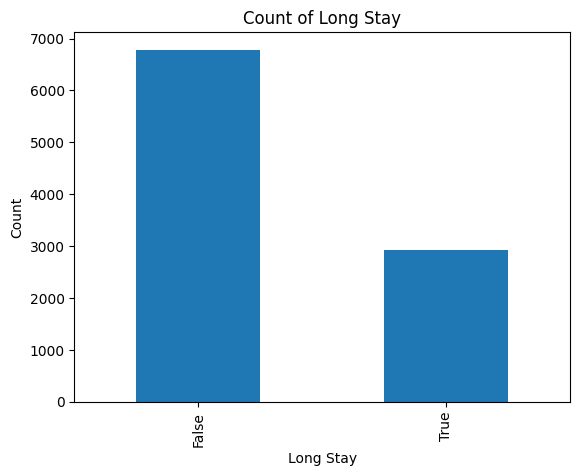

In [ ]:
counts = df['long_stay'].value_counts()

counts.plot(kind='bar')
plt.xlabel('Long Stay')
plt.ylabel('Count')
plt.title('Count of Long Stay')
plt.show()

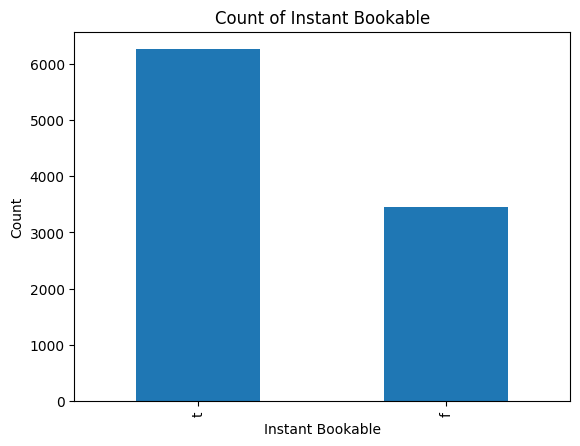

In [530]:
counts = df['instant_bookable'].value_counts()

counts.plot(kind='bar')
plt.xlabel('Instant Bookable')
plt.ylabel('Count')
plt.title('Count of Instant Bookable')
plt.show()

In [531]:
df['instant_bookable'] = (df['instant_bookable'] == 't')

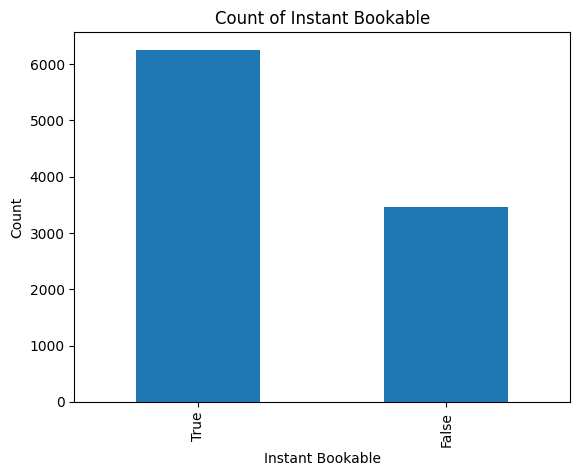

In [532]:
counts = df['instant_bookable'].value_counts()

counts.plot(kind='bar')
plt.xlabel('Instant Bookable')
plt.ylabel('Count')
plt.title('Count of Instant Bookable')
plt.show()